# Generalized Log Template Parser

Clean final notebook for training, evaluating, and analyzing the memory-augmented meta-learning log parser.


In [1]:
# Dependency Setup
import importlib.util
import subprocess
import sys

for package in ("sentence_transformers", "openpyxl"):
    if importlib.util.find_spec(package) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])


In [2]:
# Configuration, Paths, and Imports
import copy
import csv
import json
import os
import random
import time
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sentence_transformers import SentenceTransformer

CONFIG = {
    "seed": 42,
    "encoder_model": "all-MiniLM-L6-v2",
    "max_lines": 2000,
    "min_tokens": 2,

    # Raw log content extraction
    "input_mode": "raw_log",
    "raw_boundary_max_tokens": 18,
    "raw_boundary_min_confidence": 0.35,
    "raw_boundary_margin": 0.08,
    "raw_boundary_profile_lines": 2000,
    "use_structured_content_teacher": True,

    # Model
    "mem_dim": 128,
    "hidden_dim": 128,
    "n_slots": 256,
    "ema_alpha": 0.90,
    "mlp_dropout": 0.10,
    "same_cos_th": 0.85,
    "diff_cos_th": 0.30,
    "th_conservatism": 0.10,
    "classifier_threshold": 0.62,
    "memory_label_weight": 0.30,
    "memory_min_sim": 0.72,
    "memory_max_items": 4096,
    "use_token_rule_features": True,
    "template_print_rows": 250,
    "write_predicted_label_memory": False,
    "predicted_memory_min_confidence": 0.18,
    "template_reuse_enabled": True,
    "template_reuse_min_score": 0.82,
    "template_reuse_min_new_static_coverage": 0.90,
    "template_reuse_min_existing_static_coverage": 0.55,
    "template_reuse_max_length_delta": 0.50,
    "template_reuse_promote_count": 3,
    "template_bank_max_items": 4096,

    # Training
    "pos_weight_cap": 3.50,
    "pos_weight_floor": 2.50,
    "meta_lr": 1e-3,
    "inner_lr": 5e-2,
    "adapt_lr": 5e-3,
    "inner_steps": 3,
    "n_support": 10,
    "n_query": 50,
    "meta_epochs": 100,
    "tasks_per_epoch": 12,
    "print_every": 20,

    "pooled_epochs": 12,
    "pooled_batch_size": 128,

    # Evaluation and unseen adaptation
    "unseen_adapt_lines": 20,
    "unseen_adapt_steps": 5,
    "unseen_create_th_floor": 0.70,
    "pa_similarity_threshold": 0.90,
    "group_similarity_threshold": 0.90,
    "top_template_examples": 10,
}

random.seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
torch.manual_seed(CONFIG["seed"])
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PROJECT_ROOT = Path("/content") if os.path.exists("/content") else Path(".")
OUTPUT_DIR = PROJECT_ROOT / "outputs"
REPORT_DIR = OUTPUT_DIR / "reports"
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"
for directory in (OUTPUT_DIR, REPORT_DIR, FIGURE_DIR, MODEL_DIR):
    directory.mkdir(parents=True, exist_ok=True)

MAIN_WORKBOOK_PATH = REPORT_DIR / "log_template_evaluation.xlsx"
TARGETED_WORKBOOK_PATH = REPORT_DIR / "targeted_experiments.xlsx"
RESULTS_JSON_PATH = REPORT_DIR / "model_results.json"
CHECKPOINT_PATH = MODEL_DIR / "memaid_checkpoint.pt"


def pct(value):
    return "N/A" if value is None else f"{100 * value:.1f}%"


print(f"Device: {DEVICE}")
print(f"Input mode: {CONFIG['input_mode']}")
print(f"Episode setup: support={CONFIG['n_support']} query={CONFIG['n_query']} unseen_adapt_lines={CONFIG['unseen_adapt_lines']}")


Device: cpu
Input mode: raw_log
Training labels: ground-truth EventTemplate alignment only
Episode setup: support=10 query=50 unseen_adapt_lines=20


In [3]:
# Content, Raw Metadata, and Token Utilities
#
# Raw logs often start with timestamp, level, process, host, or thread metadata.
# This cell removes that prefix with batch statistics and plain string logic;

_ALIGNMENT_STRIP = "[](),;'\""
_EDGE_PUNCTUATION = "[](){}'\"`,.;:"
_LOG_LEVELS = {
    "trace", "debug", "info", "information", "warn", "warning",
    "error", "err", "fatal", "critical", "severe", "notice",
    "verbose", "v", "d", "i", "w", "e", "a",
}
_METADATA_SEPARATORS = set("-_/.:@[](){}<>|=,+")


def clean_text(value):
    if value is None:
        return ""
    if isinstance(value, float) and pd.isna(value):
        return ""
    return str(value).strip()


def tokenize_content(content):
    return clean_text(content).split()


def _strip_outer_punctuation(token):
    return clean_text(token).strip(_EDGE_PUNCTUATION)


def _lower_core(token):
    return _strip_outer_punctuation(token).lower()


def _has_digit(text):
    return any(ch.isdigit() for ch in clean_text(text))


def _has_alpha(text):
    return any(ch.isalpha() for ch in clean_text(text))


def _char_fraction(text, predicate):
    text = clean_text(text)
    return 0.0 if not text else sum(1 for ch in text if predicate(ch)) / len(text)


def _symbol_fraction(text):
    return _char_fraction(text, lambda ch: not ch.isalnum())


def _digit_fraction(text):
    return _char_fraction(text, lambda ch: ch.isdigit())


def _token_has_separator(token):
    return any(ch in _METADATA_SEPARATORS for ch in clean_text(token))


def _is_log_level_token(token):
    return _lower_core(token) in _LOG_LEVELS


def _strip_light_punctuation_for_template(token):
    text = clean_text(token)
    while text and text[0] in '([{"\'':
        text = text[1:]
    while text and text[-1] in ')]},;"\'':
        text = text[:-1]
    return text


def _collapse_adjacent_wildcards(parts):
    collapsed = []
    for part in parts:
        if part == "<*>" and collapsed and collapsed[-1] == "<*>":
            continue
        collapsed.append(part)
    return collapsed


def _clean_template_spacing_basic(template):
    text = " ".join(clean_text(template).split())
    for punct in [",", ".", ";", ":", ")", "]", "}", ">"]:
        text = text.replace(f" {punct}", punct)
    for punct in ["(", "[", "{", "<"]:
        text = text.replace(f"{punct} ", punct)
    return text.strip()


def template_from_labeled_tokens(tokens, labels):
    parts = ["<*>" if int(label) else str(token) for token, label in zip(tokens, labels)]
    return _clean_template_spacing_basic(" ".join(_collapse_adjacent_wildcards(parts)))


In [4]:
# Raw Log Content Extraction and Record Builder

class RawMetadataBoundaryDetector:
    """Find the start of the message body in raw log lines.

    The detector first learns simple position statistics from the current batch.
    Early metadata positions usually have many unique values, many digits, and
    heavy punctuation. Message positions usually contain repeated words and more
    natural language tokens. Each raw line is then scored at possible boundary
    positions, and the best high-confidence boundary is used as content start.
    """

    def __init__(self, cfg=CONFIG):
        self.cfg = cfg
        self.max_boundary = int(cfg.get("raw_boundary_max_tokens", 18))
        self.min_tokens = int(cfg.get("min_tokens", 2))
        self.position_stats = {}

    def fit(self, indexed_lines):
        rows = [tokenize_content(line) for _, line in indexed_lines]
        rows = [row for row in rows if row]
        if self.cfg.get("raw_boundary_profile_lines"):
            rows = rows[: int(self.cfg["raw_boundary_profile_lines"])]

        stats = {}
        max_pos = min(self.max_boundary + 8, max((len(row) for row in rows), default=0))
        for pos in range(max_pos):
            values = []
            digit_hits = symbol_hits = alpha_hits = level_hits = 0
            for row in rows:
                if pos >= len(row):
                    continue
                token = row[pos]
                core = _lower_core(token)
                if not core:
                    continue
                values.append(core)
                digit_hits += int(_has_digit(core))
                symbol_hits += int(_symbol_fraction(token) >= 0.20)
                alpha_hits += int(_has_alpha(core))
                level_hits += int(core in _LOG_LEVELS)

            total = len(values)
            if not total:
                continue
            stats[pos] = {
                "total": total,
                "unique_ratio": len(set(values)) / total,
                "digit_ratio": digit_hits / total,
                "symbol_ratio": symbol_hits / total,
                "alpha_ratio": alpha_hits / total,
                "level_ratio": level_hits / total,
            }
        self.position_stats = stats
        return self

    def _metadata_likelihood(self, token, pos):
        core = _lower_core(token)
        if not core:
            return 0.0

        score = 0.0
        early = pos < self.max_boundary
        if early and core in _LOG_LEVELS:
            score += 0.70
        if early and _has_digit(core):
            score += 0.25
        if early and _symbol_fraction(token) >= 0.25:
            score += 0.20
        if early and _token_has_separator(token) and (_has_digit(token) or len(core) <= 8):
            score += 0.15
        if early and pos > 0 and clean_text(token).endswith(":") and _has_alpha(core):
            score += 0.45
        if clean_text(token).startswith("[") or clean_text(token).endswith("]"):
            score += 0.10 if early else 0.02

        pos_stats = self.position_stats.get(pos)
        if pos_stats:
            if pos_stats["unique_ratio"] >= 0.70 and (_has_digit(core) or _symbol_fraction(token) >= 0.15):
                score += 0.25
            if pos_stats["digit_ratio"] >= 0.55 and _has_digit(core):
                score += 0.15
            if pos_stats["level_ratio"] >= 0.10 and core in _LOG_LEVELS:
                score += 0.20
            if pos_stats["unique_ratio"] <= 0.25 and core not in _LOG_LEVELS and not _has_digit(core):
                score -= 0.15

        if not early:
            score *= 0.45
        return max(0.0, min(1.0, score))

    def _content_likelihood(self, token, pos):
        core = _lower_core(token)
        if not core:
            return 0.0

        score = 0.35
        if _has_alpha(core):
            score += 0.25
        if not _has_digit(core):
            score += 0.12
        if _symbol_fraction(token) < 0.35:
            score += 0.10
        if core in _LOG_LEVELS and pos < self.max_boundary:
            score -= 0.30
        if pos > 0 and clean_text(token).endswith(":") and pos < self.max_boundary:
            score -= 0.45

        pos_stats = self.position_stats.get(pos)
        if pos_stats:
            if pos_stats["unique_ratio"] <= 0.60:
                score += 0.12
            if pos_stats["digit_ratio"] <= 0.50:
                score += 0.08
            if pos_stats["symbol_ratio"] <= 0.60:
                score += 0.05

        score -= 0.45 * self._metadata_likelihood(token, pos)
        return max(0.0, min(1.0, score))

    def _candidate_boundaries(self, tokens):
        limit = min(self.max_boundary, max(0, len(tokens) - self.min_tokens))
        return list(range(limit + 1))

    def _transition_bonus(self, tokens, boundary):
        if boundary <= 0 or boundary >= len(tokens):
            return 0.0
        before = clean_text(tokens[boundary - 1])
        after = clean_text(tokens[boundary])
        before_core = _lower_core(before)
        bonus = 0.0
        if before_core in _LOG_LEVELS:
            bonus += 0.25
        if before in {"-", "|", "::"}:
            bonus += 0.20
        if boundary >= 2 and (before.endswith(":") or before.endswith("]") or before.endswith("]:")):
            bonus += 0.22
        if after and after[0].isupper():
            bonus += 0.05
        return bonus

    def _mean_score(self, tokens, start, end, scoring_fn):
        values = [scoring_fn(tokens[pos], pos) for pos in range(start, min(end, len(tokens)))]
        return float(np.mean(values)) if values else 0.0

    def _score_boundary(self, tokens, boundary):
        if not tokens:
            return 0.0

        if boundary == 0:
            first_content = self._mean_score(tokens, 0, min(6, len(tokens)), self._content_likelihood)
            first_metadata = self._mean_score(tokens, 0, min(4, len(tokens)), self._metadata_likelihood)
            return first_content - 0.30 * first_metadata + 0.05

        prefix_metadata = self._mean_score(tokens, 0, boundary, self._metadata_likelihood)
        suffix_content = self._mean_score(tokens, boundary, boundary + 8, self._content_likelihood)
        suffix_metadata = self._mean_score(tokens, boundary, min(boundary + 4, len(tokens)), self._metadata_likelihood)
        content_len = len(tokens) - boundary
        length_bonus = min(content_len / 10.0, 1.0) * 0.08
        late_penalty = (boundary / max(self.max_boundary, 1)) * 0.10
        return (
            0.56 * prefix_metadata
            + 0.48 * suffix_content
            - 0.30 * suffix_metadata
            + self._transition_bonus(tokens, boundary)
            + length_bonus
            - late_penalty
        )

    def detect(self, raw_line):
        raw_line = clean_text(raw_line)
        tokens = tokenize_content(raw_line)
        if len(tokens) <= self.min_tokens:
            return {
                "content": raw_line,
                "tokens": tokens,
                "boundary_pos": 0,
                "boundary_score": 0.0,
                "boundary_mode": "raw_full_line",
            }

        candidates = self._candidate_boundaries(tokens)
        scored = [(self._score_boundary(tokens, boundary), boundary) for boundary in candidates]
        full_line_score = next(score for score, boundary in scored if boundary == 0)
        best_score, best_boundary = max(scored, key=lambda item: item[0])

        confidence = float(self.cfg.get("raw_boundary_min_confidence", 0.35))
        margin = float(self.cfg.get("raw_boundary_margin", 0.08))
        if best_boundary > 0 and best_score >= confidence and best_score >= full_line_score + margin:
            boundary = best_boundary
            mode = "raw_statistical_boundary"
            score = best_score
        else:
            boundary = 0
            mode = "raw_full_line"
            score = full_line_score

        content_tokens = tokens[boundary:]
        return {
            "content": " ".join(content_tokens),
            "tokens": content_tokens,
            "boundary_pos": boundary,
            "boundary_score": float(score),
            "boundary_mode": mode,
        }


class UniversalLogParser:
    """Build records from raw logs or structured content."""

    def __init__(self, cfg=CONFIG):
        self.cfg = cfg
        self.boundary_detector = RawMetadataBoundaryDetector(cfg)

    def parse(self, line, line_number=None):
        raw_line = clean_text(line)
        detected = self.boundary_detector.detect(raw_line)
        return {
            "raw_line": raw_line,
            "line_number": line_number,
            "format_type": "raw_log",
            "metadata": {"boundary_tokens_removed": detected["boundary_pos"]},
            "content": detected["content"],
            "tokens": detected["tokens"],
            "token_labels": None,
            "boundary_mode": detected["boundary_mode"],
            "boundary_pos": detected["boundary_pos"],
            "boundary_score": detected["boundary_score"],
            "gt_labels": None,
            "gt_template": None,
            "gt_content": None,
        }

    def parse_structured(self, line_id, content, gt_template=None, raw_line=None):
        content = clean_text(content)
        tokens = tokenize_content(content)
        return {
            "raw_line": clean_text(raw_line) or content,
            "line_number": int(line_id) if line_id is not None else None,
            "format_type": "structured_csv",
            "metadata": {},
            "content": content,
            "tokens": tokens,
            "token_labels": None,
            "boundary_mode": "structured_content",
            "boundary_pos": 0,
            "boundary_score": None,
            "gt_labels": None,
            "gt_template": clean_text(gt_template),
            "gt_content": content,
        }

    def parse_batch(self, indexed_lines):
        indexed_lines = list(indexed_lines)
        self.boundary_detector.fit(indexed_lines)
        return [self.parse(line, line_number=line_id) for line_id, line in indexed_lines]


def _column_by_lowercase(df, expected_name):
    expected = expected_name.lower()
    return next((col for col in df.columns if str(col).lower() == expected), None)


def records_from_structured_csv(structured_csv_path, raw_lookup=None, cfg=CONFIG):
    if not structured_csv_path or not os.path.exists(structured_csv_path):
        return None

    df = pd.read_csv(structured_csv_path).head(cfg["max_lines"])
    line_col = _column_by_lowercase(df, "lineid")
    content_col = _column_by_lowercase(df, "content")
    template_col = _column_by_lowercase(df, "eventtemplate")
    if content_col is None:
        return None

    parser = UniversalLogParser(cfg)
    records = []
    for row_index, row in df.iterrows():
        line_id = int(row[line_col]) if line_col and pd.notna(row[line_col]) else row_index + 1
        content = row[content_col]
        gt_template = row[template_col] if template_col and pd.notna(row[template_col]) else ""
        raw_line = raw_lookup.get(line_id) if raw_lookup else None
        record = parser.parse_structured(line_id, content, gt_template=gt_template, raw_line=raw_line)
        if len(record["tokens"]) >= cfg["min_tokens"]:
            records.append(record)
    return records


In [5]:
# Ground Truth Alignment

def _trim_align_token(token):
    text = clean_text(token).strip(_ALIGNMENT_STRIP)
    while text and text[-1] in ",;:":
        text = text[:-1]
    return text


def _wildcard_surface_match(pattern, value):
    pattern = clean_text(pattern)
    value = clean_text(value)
    if pattern == "<*>":
        return bool(value)
    if "<*>" not in pattern:
        return pattern == value

    pieces = pattern.split("<*>")
    pos = 0
    if pieces[0] and not value.startswith(pieces[0]):
        return False
    for idx, piece in enumerate(pieces):
        if not piece:
            continue
        found = value.find(piece, pos)
        if found < 0:
            return False
        pos = found + len(piece)
    if pieces[-1] and not value.endswith(pieces[-1]):
        return False
    return True


def _gt_token_matches(gt_tok, content_tok):
    gt_raw = clean_text(gt_tok)
    content_raw = clean_text(content_tok)
    gt_clean = _trim_align_token(gt_raw)
    content_clean = _trim_align_token(content_raw)

    if gt_raw == "<*>":
        return bool(content_raw)
    if "<*>" in gt_raw:
        return (
            _wildcard_surface_match(gt_raw, content_raw)
            or _wildcard_surface_match(gt_clean, content_clean)
            or _wildcard_surface_match(gt_clean, content_raw)
        )
    return content_raw == gt_raw or content_clean == gt_clean


def _gt_token_label(gt_tok):
    return 1 if "<*>" in clean_text(gt_tok) else 0


def extract_gt_labels(content_tokens, gt_template):
    """Align one GT template to one tokenized content line. Returns None on mismatch."""
    if not gt_template or not content_tokens:
        return None

    gt_toks = clean_text(gt_template).split()
    labels = []
    ci = gi = 0

    while gi < len(gt_toks):
        gt_tok = gt_toks[gi]

        if gt_tok == "<*>":
            next_static = None
            for j in range(gi + 1, len(gt_toks)):
                if gt_toks[j] != "<*>":
                    next_static = j
                    break

            if next_static is None:
                if ci >= len(content_tokens):
                    return None
                labels.extend([1] * (len(content_tokens) - ci))
                ci = len(content_tokens)
                gi = len(gt_toks)
                break

            next_gt = gt_toks[next_static]
            start = ci
            while ci < len(content_tokens) and not _gt_token_matches(next_gt, content_tokens[ci]):
                labels.append(1)
                ci += 1
            if ci == start or ci >= len(content_tokens):
                return None
            gi += 1
            continue

        if ci >= len(content_tokens) or not _gt_token_matches(gt_tok, content_tokens[ci]):
            return None
        labels.append(_gt_token_label(gt_tok))
        ci += 1
        gi += 1

    if ci != len(content_tokens) or len(labels) != len(content_tokens):
        return None
    return labels


def _tokens_equal_for_subsequence(left, right):
    return _trim_align_token(left).lower() == _trim_align_token(right).lower()


def labels_from_structured_content(parsed_tokens, gt_template, structured_content):
    if not structured_content or not parsed_tokens:
        return None
    content_tokens = tokenize_content(structured_content)
    full_labels = extract_gt_labels(content_tokens, gt_template)
    if full_labels is None:
        return None

    n = len(parsed_tokens)
    for start in range(0, len(content_tokens) - n + 1):
        window = content_tokens[start:start + n]
        if all(_tokens_equal_for_subsequence(a, b) for a, b in zip(parsed_tokens, window)):
            return full_labels[start:start + n]
    return None


def load_ground_truth_structured(structured_csv_path):
    if not structured_csv_path or not os.path.exists(structured_csv_path):
        return {}
    df = pd.read_csv(structured_csv_path)
    line_col = _column_by_lowercase(df, "lineid")
    template_col = _column_by_lowercase(df, "eventtemplate")
    content_col = _column_by_lowercase(df, "content")
    if line_col is None or template_col is None:
        return {}

    gt = {}
    for _, row in df.iterrows():
        try:
            line_id = int(row[line_col])
        except Exception:
            continue
        gt[line_id] = {
            "template": clean_text(row[template_col]),
            "content": clean_text(row[content_col]) if content_col else "",
        }
    return gt


def attach_ground_truth(records, gt_map=None):
    gt_map = gt_map or {}
    stats = Counter()
    for record in records:
        line_id = int(record.get("line_number") or -1)
        info = gt_map.get(line_id, {})
        gt_template = clean_text(info.get("template") or record.get("gt_template"))
        gt_content = clean_text(info.get("content") or record.get("gt_content") or record.get("content"))

        record["gt_template"] = gt_template or None
        record["gt_content"] = gt_content or None
        record["gt_labels"] = None
        record["gt_alignment"] = None
        record["token_labels"] = None

        if not gt_template:
            stats["missing_template"] += 1
            continue

        stats["template_attached"] += 1
        labels = extract_gt_labels(record.get("tokens", []), gt_template)
        if labels is not None:
            record["gt_labels"] = labels
            record["token_labels"] = labels
            record["gt_alignment"] = "parsed_content"
            stats["labels_exact"] += 1
            continue

        labels = labels_from_structured_content(record.get("tokens", []), gt_template, gt_content)
        if labels is not None:
            record["gt_labels"] = labels
            record["token_labels"] = labels
            record["gt_alignment"] = "structured_content_subsequence"
            stats["labels_from_content"] += 1
        else:
            stats["labels_unaligned"] += 1
    return dict(stats)



def correct_training_boundaries_with_gt(records):
    stats = Counter()
    for record in records:
        gt_content = clean_text(record.get("gt_content"))
        gt_template = record.get("gt_template")
        if not gt_content or not gt_template:
            stats["missing_gt_content"] += 1
            continue

        gt_tokens = tokenize_content(gt_content)
        labels = extract_gt_labels(gt_tokens, gt_template)
        if labels is None or len(labels) != len(gt_tokens):
            stats["gt_content_unaligned"] += 1
            continue

        parsed_tokens = record.get("tokens", [])
        same = (
            len(parsed_tokens) == len(gt_tokens)
            and all(_tokens_equal_for_subsequence(a, b) for a, b in zip(parsed_tokens, gt_tokens))
        )
        if same:
            stats["already_correct"] += 1
        else:
            record["content_before_gt_boundary_fix"] = record.get("content")
            record["tokens_before_gt_boundary_fix"] = list(parsed_tokens)
            record["boundary_mode"] = f"{record.get('boundary_mode', 'unknown')}+gt_content"
            record["content"] = gt_content
            record["tokens"] = gt_tokens
            stats["gt_boundary_corrected"] += 1

        record["gt_labels"] = labels
        record["token_labels"] = labels
        record["gt_alignment"] = "gt_content"
    return dict(stats)


def _find_token_subsequence(haystack_tokens, needle_tokens):
    if not haystack_tokens or not needle_tokens or len(needle_tokens) > len(haystack_tokens):
        return None
    n = len(needle_tokens)
    for start in range(0, len(haystack_tokens) - n + 1):
        window = haystack_tokens[start:start + n]
        if all(_tokens_equal_for_subsequence(a, b) for a, b in zip(window, needle_tokens)):
            return start
    return None


def _copy_boundary_before_teacher(record):
    if "content_before_structured_teacher" not in record:
        record["content_before_structured_teacher"] = record.get("content")
        record["tokens_before_structured_teacher"] = list(record.get("tokens", []))
        record["boundary_pos_before_structured_teacher"] = record.get("boundary_pos")
        record["boundary_mode_before_structured_teacher"] = record.get("boundary_mode")


def correct_raw_boundaries_with_structured_teacher(records, enabled=True):
    """Use structured Content to validate/correct raw metadata boundaries when GT is available.

    This is used only for labeled benchmark preparation. The raw detector still
    runs first, and pure raw inference does not require structured Content.
    """
    stats = Counter()
    if not enabled:
        return dict(stats)

    for record in records:
        gt_template = clean_text(record.get("gt_template"))
        gt_content = clean_text(record.get("gt_content"))
        if not gt_template or not gt_content:
            stats["missing_teacher"] += 1
            continue

        gt_tokens = tokenize_content(gt_content)
        teacher_labels = extract_gt_labels(gt_tokens, gt_template)
        if teacher_labels is None or len(teacher_labels) != len(gt_tokens):
            stats["teacher_unaligned"] += 1
            continue

        current_labels = extract_gt_labels(record.get("tokens", []), gt_template)
        if current_labels is not None and len(current_labels) == len(record.get("tokens", [])):
            record["gt_labels"] = current_labels
            record["token_labels"] = current_labels
            record["gt_alignment"] = record.get("gt_alignment") or "raw_detected_content"
            stats["raw_boundary_ok"] += 1
            continue

        raw_tokens = tokenize_content(record.get("raw_line"))
        start = _find_token_subsequence(raw_tokens, gt_tokens)
        if start is not None:
            corrected_tokens = raw_tokens[start:start + len(gt_tokens)]
            corrected_labels = extract_gt_labels(corrected_tokens, gt_template)
            if corrected_labels is None or len(corrected_labels) != len(corrected_tokens):
                corrected_tokens = gt_tokens
                corrected_labels = teacher_labels

            _copy_boundary_before_teacher(record)
            record["content"] = " ".join(corrected_tokens)
            record["tokens"] = corrected_tokens
            record["boundary_pos"] = start
            record["boundary_mode"] = "raw_boundary_corrected_by_structured_teacher"
            record["gt_labels"] = corrected_labels
            record["token_labels"] = corrected_labels
            record["gt_alignment"] = "raw_boundary_corrected_by_structured_teacher"
            stats["raw_boundary_corrected"] += 1
            continue

        _copy_boundary_before_teacher(record)
        record["content"] = gt_content
        record["tokens"] = gt_tokens
        record["boundary_pos"] = None
        record["boundary_mode"] = "structured_teacher_content_fallback"
        record["gt_labels"] = teacher_labels
        record["token_labels"] = teacher_labels
        record["gt_alignment"] = "structured_teacher_content_fallback"
        stats["structured_teacher_fallback"] += 1

    return dict(stats)


def get_training_labels(record):
    labels = record.get("gt_labels")
    if labels is None:
        return None
    return labels if len(labels) == len(record.get("tokens", [])) else None


def training_label_source(record):
    return "gt" if get_training_labels(record) is not None else "skipped"


def _score_token_labels(preds, gt_labels, gt_token_count=None):
    if not gt_labels:
        return 0, 0
    correct = 0
    for pred, gt in zip(preds, gt_labels):
        correct += int(pred == gt)
    total = max(len(preds), len(gt_labels))
    if gt_token_count is not None and gt_token_count > total:
        total = gt_token_count
    return correct, total


In [6]:
# Sentence Encoder
class Encoder:
    """
    Wraps all-MiniLM-L6-v2 (22M params, 384-dim, pre-trained on 1B+ pairs).
    Encoder weights are frozen. W_proj and svd_mean are computed once from
    training data and then reused consistently during training and inference.
    """

    def __init__(self, model_name=CONFIG["encoder_model"]):
        self.model = SentenceTransformer(model_name)
        self.dim = self.model.get_sentence_embedding_dimension()
        self.W_proj = None
        self.svd_mean = None
        self.svd_variance = None

    def encode(self, texts, show_progress=False):
        return self.model.encode(
            texts, normalize_embeddings=True,
            show_progress_bar=show_progress, batch_size=64
        ).astype(np.float32)

    def fit_svd(self, embeddings, target_dim=None):
        """
        Fit centered SVD and store W_proj in R^(D x input_dim).
        The training mean is stored and reused for every future projection.
        """
        D = target_dim or CONFIG["mem_dim"]
        X = np.stack(embeddings).astype(np.float64)
        mean = X.mean(axis=0, keepdims=True)
        Xc = X - mean
        _, S, Vt = np.linalg.svd(Xc, full_matrices=False)
        n = min(len(embeddings), D)
        if n >= D:
            W = Vt[:D].astype(np.float32)
            var = float((S[:D] ** 2).sum() / (S ** 2).sum())
        else:
            rng = np.random.default_rng(CONFIG["seed"])
            pad = rng.normal(0, 1, (D - n, self.dim)).astype(np.float32)
            pad /= np.linalg.norm(pad, axis=1, keepdims=True)
            W = np.vstack([Vt[:n].astype(np.float32), pad])
            var = float((S[:n] ** 2).sum() / (S ** 2).sum())
        self.W_proj = torch.tensor(W, dtype=torch.float32)
        self.svd_mean = mean.squeeze(0).astype(np.float32)
        self.svd_variance = var
        return self.W_proj


def project_embeddings(embeddings, W_proj, svd_mean=None, device=None):
    """Apply the single official SVD projection path: (x - mean) @ W_proj.T."""
    x = torch.as_tensor(embeddings, dtype=torch.float32, device=device)
    single = x.dim() == 1
    if single:
        x = x.unsqueeze(0)
    W = torch.as_tensor(W_proj, dtype=torch.float32, device=x.device)
    if svd_mean is not None:
        mean = torch.as_tensor(svd_mean, dtype=torch.float32, device=x.device)
        x = x - mean
    projected = torch.nn.functional.normalize(x @ W.T, dim=-1)
    return projected.squeeze(0) if single else projected


def project_records(records, embeddings, W_proj, svd_mean=None):
    projected = project_embeddings(embeddings, W_proj, svd_mean).detach().cpu()
    for r, emb, x_proj in zip(records, embeddings, projected):
        r["x_np"] = np.asarray(emb, dtype=np.float32)
        r["x"] = x_proj.clone()
    return records


In [7]:
# Memory-Augmented Neural Layer

class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.1):
        super().__init__()
        mid = (in_dim + out_dim) // 2
        self.net = nn.Sequential(
            nn.Linear(in_dim, mid), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(mid, out_dim), nn.ReLU(),
        )
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x, verbose=False):
        return self.net(x)


class MANNLayer(nn.Module):
    def __init__(self, W_proj_tensor, create_th, cfg=CONFIG, svd_mean=None):
        super().__init__()
        D, H, NS = cfg["mem_dim"], cfg["hidden_dim"], cfg["n_slots"]
        self.D = D
        self.H = H
        self.n_slots = NS
        self.base_alpha = cfg["ema_alpha"]
        self.create_th = create_th

        self.register_buffer("W_proj", torch.as_tensor(W_proj_tensor, dtype=torch.float32))
        if svd_mean is None:
            svd_mean = torch.zeros(self.W_proj.shape[1], dtype=torch.float32)
        self.register_buffer("svd_mean", torch.as_tensor(svd_mean, dtype=torch.float32))

        self.controller = MLP(D, H, cfg["mlp_dropout"])
        self.W_q = nn.Linear(H, D, bias=False)
        self.W_o = nn.Linear(H + D, H, bias=True)
        self.W_gate = nn.Linear(H + D, D, bias=True)

        nn.init.xavier_uniform_(self.W_q.weight)
        nn.init.xavier_uniform_(self.W_o.weight)
        nn.init.zeros_(self.W_o.bias)
        nn.init.xavier_uniform_(self.W_gate.weight)
        nn.init.zeros_(self.W_gate.bias)

        self.register_buffer("M", torch.zeros(NS, D))
        self.register_buffer("usage", torch.zeros(NS))

    def reset_memory(self):
        self.M.zero_()
        self.usage.zero_()

    def _adaptive_alpha(self, idx):
        """Slower updates for mature slots, fast convergence for new ones."""
        return self.base_alpha / (self.usage[idx].item() ** 0.5 + 1.0)

    def _project(self, x):
        if x.shape[-1] == self.D:
            return nn.functional.normalize(x, dim=-1)
        if x.shape[-1] != self.W_proj.shape[1]:
            raise ValueError(f"Expected {self.D}d projected or {self.W_proj.shape[1]}d raw embedding, got {x.shape[-1]}d")
        return nn.functional.normalize((x - self.svd_mean.to(x.device)) @ self.W_proj.to(x.device).T, dim=-1)

    def forward(self, x, verbose=False, write=True):
        batched = x.dim() == 2
        if not batched:
            x = x.unsqueeze(0)

        x_proj = self._project(x)
        h = self.controller(x_proj)

        # Snapshot before any write. Read uses the previous memory state only.
        M_snap = self.M.detach().clone()
        usage_snap = self.usage.detach().clone()

        n_active = int((usage_snap > 0).sum().item())
        if n_active == 0:
            r = torch.zeros(x.size(0), self.D, device=x.device)
            if verbose:
                print(f"    Read  : memory empty, r = zeros({self.D})")
        else:
            q = nn.functional.normalize(self.W_q(h), dim=-1)
            M_norm = nn.functional.normalize(M_snap, dim=-1)
            scores = q @ M_norm.T
            mask = (usage_snap > 0).float().to(x.device)
            scores = scores * mask + (1 - mask) * (-1e9)
            attn = torch.softmax(scores, dim=-1)
            r = attn @ M_snap.to(x.device)
            if verbose:
                top_slot = attn[0].argmax().item()
                top_sim = scores[0, top_slot].item()
                print(f"    Read  : {n_active} active slots, best=slot[{top_slot}] sim={top_sim:.3f}")

        if write:
            with torch.no_grad():
                M_new = M_snap.clone()
                for b in range(x.size(0)):
                    xn = nn.functional.normalize(x_proj[b].detach(), dim=0).to(self.M.device)
                    na = int((self.usage > 0).sum().item())
                    if na == 0:
                        M_new[0] = xn
                        self.usage[0] = 1.0
                        continue
                    M_n = nn.functional.normalize(M_new, dim=-1)
                    sims = (M_n @ xn) * (self.usage > 0).float() + (self.usage == 0).float() * (-1e9)
                    best = sims.argmax().item()
                    if sims[best].item() >= self.create_th:
                        alpha = self._adaptive_alpha(best)
                        M_new[best] = nn.functional.normalize((1 - alpha) * M_new[best] + alpha * xn, dim=0)
                        self.usage[best] += 1.0
                    else:
                        free = (self.usage == 0).nonzero(as_tuple=True)[0]
                        slot = free[0].item() if len(free) > 0 else self.usage.argmin().item()
                        M_new[slot] = xn
                        self.usage[slot] = 1.0
                self.M.copy_(M_new)

        hr = torch.cat([h, r], dim=-1)
        gate = torch.sigmoid(self.W_gate(hr))
        gated_r = gate * r
        z = nn.functional.normalize(torch.tanh(self.W_o(torch.cat([h, gated_r], dim=-1))), dim=-1)
        if verbose:
            gate_avg = gate[0].mean().item()
            print(f"    Gate   : mean={gate_avg:.3f} (0=ignore memory, 1=full memory)")
            print(f"    Output : h({self.H}) + gated_r({self.D}) -> W_o -> z({self.H})")

        return z.squeeze(0) if not batched else z


In [8]:
# Token Classifier and MemAID Model

def _memory_token_surface(tok):
    return str(tok or "").strip().strip("[](){}'\"`,.;:").lower()


def _safe_token_text(token):
    return str(token or "").strip()


def _strip_light_punctuation(token):
    return _safe_token_text(token).strip(" \t\n\r\"'`.,;()[]{}")


def _has_digit(text):
    return any(ch.isdigit() for ch in text)


def _has_alpha(text):
    return any(ch.isalpha() for ch in text)


def _char_ratio(text, predicate):
    if not text:
        return 0.0
    return sum(1 for ch in text if predicate(ch)) / len(text)


def _is_key_like(text):
    key = _strip_light_punctuation(text)
    if not key or not _has_alpha(key):
        return False
    return all(ch.isalnum() or ch in "._-" for ch in key)


def _render_predicted_variable_token(token):
    text = _safe_token_text(token)
    for sep in ("=", ":"):
        if sep in text:
            key, value = text.split(sep, 1)
            if value and _is_key_like(key):
                return f"{key}{sep}<*>"
    return "<*>"


def _clean_template_spacing_no_regex(template):
    text = " ".join(str(template or "").split())

    for punct in [",", ".", ";", ":", ")", "]", "}", ">"]:
        text = text.replace(f" {punct}", punct)

    for punct in ["(", "[", "{", "<"]:
        text = text.replace(f"{punct} ", punct)

    for old, new in [
        (" ## ", "##"),
        ("## ", "##"),
        (" ##", "##"),
        (" = ", "="),
        ("<*> '", "<*>'"),
    ]:
        text = text.replace(old, new)

    return text.strip()


def _template_tokens_no_regex(template):
    return tokenize_content(_clean_template_spacing_no_regex(template))


def _template_static_token(token):
    if "<*>" in str(token):
        return ""
    core = _memory_token_surface(token)
    return core if core and _has_alpha(core) else ""


def _template_static_sequence(template):
    return [
        value for value in (_template_static_token(tok) for tok in _template_tokens_no_regex(template))
        if value
    ]


def _lcs_equal_count(left, right):
    n, m = len(left), len(right)
    if not n or not m:
        return 0
    dp = [[0] * (m + 1) for _ in range(n + 1)]
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            if left[i - 1] == right[j - 1]:
                dp[i][j] = dp[i - 1][j - 1] + 1
            else:
                dp[i][j] = max(dp[i - 1][j], dp[i][j - 1])
    return dp[n][m]


def _template_specificity(template):
    tokens = _template_tokens_no_regex(template)
    static_tokens = _template_static_sequence(template)
    partial_static = sum(1 for tok in tokens if "<*>" in str(tok) and _has_alpha(str(tok).replace("<*>", "")))
    return len(static_tokens) + 0.35 * partial_static


def _template_reuse_scores(existing_template, new_template):
    existing_tokens = _template_tokens_no_regex(existing_template)
    new_tokens = _template_tokens_no_regex(new_template)
    existing_static = _template_static_sequence(existing_template)
    new_static = _template_static_sequence(new_template)

    if not existing_tokens or not new_tokens or len(new_static) < 2 or len(existing_static) < 2:
        return None

    matched_static = _lcs_equal_count(new_static, existing_static)
    new_coverage = matched_static / max(len(new_static), 1)
    existing_coverage = matched_static / max(len(existing_static), 1)
    length_delta = abs(len(existing_tokens) - len(new_tokens)) / max(len(existing_tokens), len(new_tokens), 1)
    length_score = 1.0 - length_delta
    score = 0.65 * new_coverage + 0.25 * existing_coverage + 0.10 * length_score

    return {
        "score": float(score),
        "new_static_coverage": float(new_coverage),
        "existing_static_coverage": float(existing_coverage),
        "length_delta": float(length_delta),
        "matched_static": int(matched_static),
    }


class TokenClassifier(nn.Module):
    """Predicts static or variable labels for each content token."""
    FEAT_DIM = 11

    def __init__(self, hidden_dim):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(hidden_dim + self.FEAT_DIM, 48),
            nn.ReLU(),
            nn.Dropout(0.05),
            nn.Linear(48, 1),
        )
        for module in self.head:
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)

    @staticmethod
    def featurise(tok, pos, total, prev_tok="", next_tok="", mem_sim=0.0, mem_label_score=0.0):
        text = _safe_token_text(tok)
        core = _strip_light_punctuation(text)
        previous_text = _safe_token_text(prev_tok)
        next_text = _safe_token_text(next_tok)

        digit_ratio = _char_ratio(core, lambda ch: ch.isdigit())
        alpha_ratio = _char_ratio(core, lambda ch: ch.isalpha())
        upper_ratio = _char_ratio(core, lambda ch: ch.isupper())
        punctuation_ratio = _char_ratio(core, lambda ch: not ch.isalnum())
        length_norm = min(len(core) / 32.0, 1.0)
        position_norm = pos / max(total - 1, 1)
        previous_separator = float(previous_text.endswith(("=", ":", "/", "-", "_")))
        next_separator = float(next_text.startswith(("=", ":", "/", "-", "_")))
        mixed_alpha_digit = float(_has_alpha(core) and _has_digit(core))

        return torch.tensor([
            digit_ratio,
            alpha_ratio,
            upper_ratio,
            punctuation_ratio,
            length_norm,
            position_norm,
            previous_separator,
            next_separator,
            mixed_alpha_digit,
            float(mem_sim),
            float(mem_label_score),
        ], dtype=torch.float32)

    def build_feat_matrix(self, tokens, device, mem_sim=0.0, mem_label_scores=None, use_rule_features=True):
        n = len(tokens)
        if mem_label_scores is None:
            mem_label_scores = [0.0] * n

        features = torch.stack([
            self.featurise(
                tok,
                i,
                n,
                tokens[i - 1] if i > 0 else "",
                tokens[i + 1] if i + 1 < n else "",
                mem_sim,
                mem_label_scores[i] if i < len(mem_label_scores) else 0.0,
            )
            for i, tok in enumerate(tokens)
        ])

        if not use_rule_features:
            memory_only = torch.zeros_like(features)
            memory_only[:, 9] = features[:, 9]
            memory_only[:, 10] = features[:, 10]
            features = memory_only

        return features.to(device)

    def forward(self, z, feat_matrix):
        z_rep = z.unsqueeze(0).expand(feat_matrix.size(0), -1)
        return self.head(torch.cat([z_rep, feat_matrix], dim=-1)).squeeze(-1)


class MemAID(nn.Module):


    def __init__(self, encoder_dim, W_proj, create_th, cfg=CONFIG, svd_mean=None):
        super().__init__()
        self.cfg = cfg
        self.mann = MANNLayer(W_proj, create_th, cfg, svd_mean=svd_mean)
        self.classifier = TokenClassifier(cfg["hidden_dim"])
        self.memory_enabled = True
        self.label_memory = []
        self.template_memory = []

    def _compute_mem_sim(self, x):
        """Cosine similarity between input and best matching MANN slot before current write."""
        if not getattr(self, "memory_enabled", True):
            return 0.0
        n_active = int((self.mann.usage > 0).sum().item())
        if n_active == 0:
            return 0.0
        with torch.no_grad():
            x_proj = self.mann._project(x.unsqueeze(0) if x.dim() == 1 else x)
            M_n = nn.functional.normalize(self.mann.M.detach().to(x_proj.device), dim=-1)
            x_n = nn.functional.normalize(x_proj, dim=-1)
            sims = (M_n @ x_n.T).squeeze()
            usage = self.mann.usage.to(sims.device)
            sims[usage == 0] = -1.0
            return float(sims.max().item())

    def _best_memory_slot(self, x):
        if not getattr(self, "memory_enabled", True):
            return None
        n_active = int((self.mann.usage > 0).sum().item())
        if n_active == 0:
            return None
        with torch.no_grad():
            x_proj = self.mann._project(x.unsqueeze(0) if x.dim() == 1 else x)
            M_n = nn.functional.normalize(self.mann.M.detach().to(x_proj.device), dim=-1)
            x_n = nn.functional.normalize(x_proj, dim=-1)
            sims = (M_n @ x_n.T).squeeze()
            usage = self.mann.usage.to(sims.device)
            sims[usage == 0] = -1e9
            return int(sims.argmax().item())

    def _project_for_label_memory(self, x):
        with torch.no_grad():
            x_in = x.unsqueeze(0) if x.dim() == 1 else x
            return self.mann._project(x_in).squeeze(0).detach().cpu()

    def _labels_to_template(self, tokens, labels):
        parts = [
            _render_predicted_variable_token(tok) if int(label) else str(tok)
            for tok, label in zip(tokens, labels)
        ]
        return self._postprocess_template(" ".join(parts))

    def write_label_memory(self, x, tokens, labels, template=None, confidence=1.0):
        """Store a support/predicted template prototype for future memory retrieval."""
        if not getattr(self, "memory_enabled", True):
            return
        if labels is None or not tokens or len(labels) != len(tokens):
            return
        entry = {
            "x_proj": self._project_for_label_memory(x),
            "tokens": list(tokens),
            "labels": [int(v) for v in labels],
            "template": template or self._labels_to_template(tokens, labels),
            "confidence": float(confidence),
        }
        self.label_memory.append(entry)
        if self.cfg.get("template_reuse_enabled", True):
            self._remember_template(entry["template"])
        max_items = int(self.cfg.get("memory_max_items", 4096))
        if len(self.label_memory) > max_items:
            self.label_memory = self.label_memory[-max_items:]

    def _nearest_label_memory(self, x):
        if not getattr(self, "memory_enabled", True) or not self.label_memory:
            return None, 0.0
        x_proj = self._project_for_label_memory(x)
        M = torch.stack([e["x_proj"] for e in self.label_memory])
        sims = torch.mv(nn.functional.normalize(M, dim=-1), nn.functional.normalize(x_proj, dim=0))
        best = int(torch.argmax(sims).item())
        sim = float(sims[best].item()) * float(self.label_memory[best].get("confidence", 1.0))
        return self.label_memory[best], sim

    def _align_memory_labels(self, mem_tokens, mem_labels, tokens):
        n = len(tokens)
        if n == 0:
            return []
        if len(mem_tokens) == n:
            return [float(v) for v in mem_labels]

        scores = [None] * n
        used_mem = set()

        # First align stable exact surface anchors.
        for i, tok in enumerate(tokens):
            t = _memory_token_surface(tok)
            if not t:
                continue
            for j, mt in enumerate(mem_tokens):
                if j in used_mem:
                    continue
                if t == _memory_token_surface(mt):
                    scores[i] = float(mem_labels[j])
                    used_mem.add(j)
                    break

        # Then fill remaining positions by relative position.
        m = len(mem_tokens)
        for i in range(n):
            if scores[i] is not None:
                continue
            if m == 0:
                scores[i] = 0.0
            elif n == 1:
                scores[i] = float(mem_labels[min(0, m - 1)])
            else:
                j = round(i * (m - 1) / max(n - 1, 1))
                scores[i] = float(mem_labels[min(max(j, 0), m - 1)])
        return scores

    def _memory_label_scores(self, x, tokens):
        entry, sim = self._nearest_label_memory(x)
        if entry is None or sim < self.cfg.get("memory_min_sim", 0.80):
            return [0.0] * len(tokens), sim, None
        return self._align_memory_labels(entry["tokens"], entry["labels"], tokens), sim, entry.get("template")

    def _template_reuse_allowed(self, scores):
        if not scores:
            return False
        return (
            scores["score"] >= float(self.cfg.get("template_reuse_min_score", 0.82))
            and scores["new_static_coverage"] >= float(self.cfg.get("template_reuse_min_new_static_coverage", 0.90))
            and scores["existing_static_coverage"] >= float(self.cfg.get("template_reuse_min_existing_static_coverage", 0.55))
            and scores["length_delta"] <= float(self.cfg.get("template_reuse_max_length_delta", 0.50))
        )

    def _find_template_reuse_candidate(self, template):
        if not self.template_memory:
            return None, None

        best_entry = None
        best_scores = None
        best_rank = None
        for entry in self.template_memory:
            scores = _template_reuse_scores(entry["template"], template)
            if not self._template_reuse_allowed(scores):
                continue
            rank = (
                scores["score"],
                entry.get("count", 1),
                _template_specificity(entry["template"]),
            )
            if best_rank is None or rank > best_rank:
                best_entry = entry
                best_scores = scores
                best_rank = rank
        return best_entry, best_scores

    def _remember_template(self, template):
        if not template:
            return
        normalized = self._postprocess_template(template)
        for entry in self.template_memory:
            if entry["template"] == normalized:
                entry["count"] += 1
                return
        self.template_memory.append({
            "template": normalized,
            "count": 1,
            "specificity": _template_specificity(normalized),
        })
        max_items = int(self.cfg.get("template_bank_max_items", 4096))
        if len(self.template_memory) > max_items:
            self.template_memory = self.template_memory[-max_items:]

    def _stabilize_template(self, template, write=True):
        if not self.cfg.get("template_reuse_enabled", True):
            return template, {"action": "disabled", "score": None}

        normalized = self._postprocess_template(template)
        entry, scores = self._find_template_reuse_candidate(normalized)
        if entry is None:
            if write:
                self._remember_template(normalized)
            return normalized, {"action": "new_template", "score": None}

        new_specificity = _template_specificity(normalized)
        old_specificity = _template_specificity(entry["template"])
        promote_limit = int(self.cfg.get("template_reuse_promote_count", 3))
        if write:
            entry["count"] += 1
            if new_specificity > old_specificity and entry["count"] <= promote_limit:
                entry["template"] = normalized
                entry["specificity"] = new_specificity
                return normalized, {"action": "template_memory_promote", **scores}

        return entry["template"], {"action": "template_memory_reuse", **scores}

    def forward(self, x, tokens, write=True, return_context=False):
        mem_sim = self._compute_mem_sim(x)
        mem_label_scores, label_sim, nearest_template = self._memory_label_scores(x, tokens)
        active_before = int((self.mann.usage > 0).sum().item())
        z = self.mann(x, write=write)
        feats = self.classifier.build_feat_matrix(
            tokens,
            x.device,
            mem_sim,
            mem_label_scores,
            use_rule_features=self.cfg.get("use_token_rule_features", True),
        )
        logits = self.classifier(z, feats)
        if return_context:
            return logits, {
                "mem_sim": mem_sim,
                "mem_label_scores": mem_label_scores,
                "label_sim": label_sim,
                "nearest_template": nearest_template,
                "active_before": active_before,
            }
        return logits

    def _decode_template(self, tokens, probs, ctx, use_heuristics=True):
        parts = []
        decisions = []
        threshold = float(self.cfg.get("classifier_threshold", 0.62))
        label_sim = float(ctx.get("label_sim", 0.0))
        mem_scores = ctx.get("mem_label_scores", [0.0] * len(tokens))
        mem_active = label_sim >= float(self.cfg.get("memory_min_sim", 0.80))
        mem_w = float(self.cfg.get("memory_label_weight", 0.30)) if mem_active else 0.0
        base_w = max(0.0, 1.0 - mem_w)

        for pos, (tok, prob) in enumerate(zip(tokens, probs)):
            prob = float(prob)
            mem_score = float(mem_scores[pos]) if pos < len(mem_scores) else 0.0
            combined = base_w * prob + mem_w * mem_score
            is_var = int(combined >= threshold)
            label = _render_predicted_variable_token(tok) if is_var else str(tok)
            reason = "memory+classifier" if mem_active else "classifier"

            decisions.append({
                "token": tok,
                "prob": prob,
                "memory_label_score": mem_score,
                "memory_similarity": label_sim,
                "combined_prob": combined,
                "label": is_var,
                "output": label,
                "reason": reason,
                "threshold": threshold,
            })
            parts.append(label)

        template = self._postprocess_template(" ".join(parts))
        return template, decisions

    def predict_line(self, x, tokens, use_heuristics=True, write=True):
        self.eval()
        with torch.no_grad():
            logits, ctx = self.forward(x, tokens, write=write, return_context=True)
            probs = torch.sigmoid(logits).tolist()
            template, decisions = self._decode_template(tokens, probs, ctx, use_heuristics)
            labels = [d["label"] for d in decisions]
            stabilized_template, template_reuse = self._stabilize_template(template, write=write)
            template = stabilized_template
            if write and self.cfg.get("write_predicted_label_memory", False):
                conf = float(np.mean([abs(d["combined_prob"] - d["threshold"]) for d in decisions])) if decisions else 0.0
                if conf >= self.cfg.get("predicted_memory_min_confidence", 0.18):
                    self.write_label_memory(x, tokens, labels, template=template, confidence=min(1.0, 0.50 + conf))
            active_after = int((self.mann.usage > 0).sum().item())
            best_slot = self._best_memory_slot(x)
        return {
            "template": template,
            "probabilities": probs,
            "labels": labels,
            "decisions": decisions,
            "logits": logits.detach().cpu(),
            "mem_sim": ctx["mem_sim"],
            "label_mem_sim": ctx["label_sim"],
            "nearest_memory_template": ctx["nearest_template"],
            "template_reuse_action": template_reuse.get("action"),
            "template_reuse_score": template_reuse.get("score"),
            "active_before": ctx["active_before"],
            "active_after": active_after,
            "best_slot": best_slot,
        }

    def predict_template(self, x, tokens, use_heuristics=True, write=True):
        return self.predict_line(x, tokens, use_heuristics=use_heuristics, write=write)["template"]

    @staticmethod
    def _postprocess_template(template):
        return _clean_template_spacing_no_regex(template)

    def reset_memory(self):
        self.mann.reset_memory()
        self.label_memory = []
        self.template_memory = []


In [9]:
# Dataset Loading
SYSTEMS = {
    "Hadoop": {"log": "/content/Hadoop_2k.log", "structured": "/content/Hadoop_2k.log_structured.csv"},
    "HDFS": {"log": "/content/HDFS_2k.log", "structured": "/content/HDFS_2k.log_structured.csv"},
    "Mac": {"log": "/content/Mac_2k.log", "structured": "/content/Mac_2k.log_structured.csv"},
    "Android": {"log": "/content/Android_2k.log", "structured": "/content/Android_2k.log_structured.csv"},
    "Windows": {"log": "/content/Windows_2k.log", "structured": "/content/Windows_2k.log_structured.csv"},
    "Linux": {"log": "/content/Linux_2k.log", "structured": "/content/Linux_2k.log_structured.csv"},
    "Apache": {"log": "/content/Apache_2k.log", "structured": "/content/Apache_2k.log_structured.csv"},
    "Zookeeper": {"log": "/content/Zookeeper_2k.log", "structured": "/content/Zookeeper_2k.log_structured.csv"},
    "OpenStack": {"log": "/content/OpenStack_2k.log", "structured": "/content/OpenStack_2k.log_structured.csv"},
    "Thunderbird": {"log": "/content/Thunderbird_2k.log", "structured": "/content/Thunderbird_2k.log_structured.csv"},
    "BGL": {"log": "/content/BGL_2k.log", "structured": "/content/BGL_2k.log_structured.csv"},
    "HealthApp": {"log": "/content/HealthApp_2k.log", "structured": "/content/HealthApp_2k.log_structured.csv"},
}


def read_log_lines(path, max_lines=CONFIG["max_lines"]):
    if not path or not os.path.exists(path):
        return []
    with open(path, encoding="utf-8", errors="ignore") as f:
        return [(i + 1, line.strip()) for i, line in enumerate(f) if line.strip()][:max_lines]


def parse_records(log_path, structured_path=None, cfg=CONFIG):
    raw_lines = read_log_lines(log_path, cfg["max_lines"])
    raw_lookup = dict(raw_lines)
    input_mode = cfg.get("input_mode", "raw_log")

    if input_mode == "raw_log" and raw_lines:
        parser = UniversalLogParser(cfg)
        records = parser.parse_batch(raw_lines)
        records = [record for record in records if len(record["tokens"]) >= cfg["min_tokens"]]
        return records, parser

    records = records_from_structured_csv(structured_path, raw_lookup=raw_lookup, cfg=cfg)
    if records is not None:
        return records, UniversalLogParser(cfg)

    parser = UniversalLogParser(cfg)
    records = parser.parse_batch(raw_lines)
    records = [record for record in records if len(record["tokens"]) >= cfg["min_tokens"]]
    return records, parser


def encode_records(records, enc, W_proj=None, svd_mean=None):
    if not records:
        return records
    embeddings = enc.encode([r["content"] for r in records])
    if W_proj is None:
        for r, emb in zip(records, embeddings):
            r["x_np"] = np.asarray(emb, dtype=np.float32)
            r["x"] = torch.tensor(emb, dtype=torch.float32)
    else:
        project_records(records, embeddings, W_proj, svd_mean)
    return records


def prepare_labeled_records(records, structured_path=None, cfg=CONFIG):
    gt_stats = attach_ground_truth(records, load_ground_truth_structured(structured_path))
    teacher_stats = {}
    boundary_stats = {}

    if cfg.get("input_mode") == "raw_log":
        teacher_stats = correct_raw_boundaries_with_structured_teacher(
            records,
            enabled=cfg.get("use_structured_content_teacher", True),
        )
    elif cfg.get("input_mode") == "structured_content":
        boundary_stats = correct_training_boundaries_with_gt(records)

    return gt_stats, teacher_stats, boundary_stats


def load_system(name, paths, enc):
    if not os.path.exists(paths.get("structured", "")) and not os.path.exists(paths.get("log", "")):
        return None

    records, parser = parse_records(paths.get("log"), paths.get("structured"))
    gt_stats, teacher_stats, boundary_stats = prepare_labeled_records(records, paths.get("structured"))

    records = [record for record in records if record_has_minimum_content(record)]
    encode_records(records, enc)
    for record in records:
        record["system"] = name

    sources = Counter(training_label_source(record) for record in records)
    boundary_modes = Counter(record.get("boundary_mode", "unknown") for record in records)
    raw_cuts = sum(1 for record in records if isinstance(record.get("boundary_pos"), int) and record.get("boundary_pos", 0) > 0)
    teacher_fixed = teacher_stats.get("raw_boundary_corrected", 0) + teacher_stats.get("structured_teacher_fallback", 0)
    print(
        f"{name:<12} records={len(records):4d} "
        f"gt={sources['gt']:4d} skipped={sources['skipped']:4d} "
        f"raw_ok={teacher_stats.get('raw_boundary_ok', 0):4d} "
        f"teacher_fixed={teacher_fixed:4d} "
        f"raw_cuts={raw_cuts:4d} "
        f"mode={boundary_modes.most_common(1)[0][0] if boundary_modes else 'none'}"
    )
    return records


def record_has_minimum_content(record):
    return len(record.get("tokens", [])) >= CONFIG["min_tokens"]


print("Loading encoder and training data")
enc = Encoder()
all_systems = {}
for system_name, paths in SYSTEMS.items():
    records = load_system(system_name, paths, enc)
    if records:
        all_systems[system_name] = records

all_flat = [r for recs in all_systems.values() for r in recs]
print(f"Loaded {len(all_systems)} systems and {len(all_flat)} records")


Loading encoder and training data


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

/tmp/ipykernel_18255/2508981399.py:11: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  self.dim = self.model.get_sentence_embedding_dimension()


Hadoop       records=1998 gt=1998 skipped=   0 raw_ok= 401 teacher_fixed=1599 raw_cuts=1998 mode=raw_boundary_corrected_by_structured_teacher
HDFS         records=2000 gt=1997 skipped=   3 raw_ok=1135 teacher_fixed= 862 raw_cuts=2000 mode=raw_statistical_boundary
Mac          records=1934 gt=1881 skipped=  53 raw_ok=1030 teacher_fixed= 917 raw_cuts=1934 mode=raw_statistical_boundary
Android      records=1458 gt=1451 skipped=   7 raw_ok=  72 teacher_fixed=1921 raw_cuts=1458 mode=raw_boundary_corrected_by_structured_teacher
Windows      records=2000 gt=1991 skipped=   9 raw_ok=  11 teacher_fixed=1980 raw_cuts=2000 mode=raw_boundary_corrected_by_structured_teacher
Linux        records=1993 gt=1082 skipped= 911 raw_ok=1019 teacher_fixed=  70 raw_cuts=1993 mode=raw_statistical_boundary
Apache       records=2000 gt=2000 skipped=   0 raw_ok=2000 teacher_fixed=   0 raw_cuts=2000 mode=raw_statistical_boundary
Zookeeper    records=1994 gt=1991 skipped=   3 raw_ok=1244 teacher_fixed= 753 raw_cuts

In [10]:
# Projection and Threshold Calibration
all_embeddings = [r["x_np"] for r in all_flat]
W_proj = enc.fit_svd(all_embeddings)
SVD_MEAN = enc.svd_mean
for recs in all_systems.values():
    project_records(recs, [r["x_np"] for r in recs], W_proj, SVD_MEAN)


def calibrate_create_th(records, W_proj, svd_mean=None, cfg=CONFIG):
    x_raw = np.stack([r["x_np"] for r in records]).astype(np.float32)
    x_proj = project_embeddings(x_raw, W_proj, svd_mean).numpy()
    x_norm = x_raw / (np.linalg.norm(x_raw, axis=1, keepdims=True) + 1e-12)
    sim_original = x_norm @ x_norm.T
    sim_projected = x_proj @ x_proj.T

    same, diff = [], []
    n = min(len(records), 200)
    for i in range(n):
        for j in range(i + 1, n):
            if sim_original[i, j] >= cfg["same_cos_th"]:
                same.append(sim_projected[i, j])
            elif sim_original[i, j] <= cfg["diff_cos_th"]:
                diff.append(sim_projected[i, j])
    if not same or not diff:
        return 0.70
    return float((np.mean(same) + np.mean(diff)) / 2.0 + cfg["th_conservatism"])


def compute_pos_weight(all_systems, cap=CONFIG["pos_weight_cap"]):
    n_static = n_var = 0
    for records in all_systems.values():
        for r in records:
            labels = get_training_labels(r)
            if labels is None:
                continue
            n_static += sum(1 - int(v) for v in labels)
            n_var += sum(int(v) for v in labels)
    raw = n_static / max(n_var, 1)
    return float(min(raw, cap))


CREATE_TH = calibrate_create_th(all_flat, W_proj, SVD_MEAN)
POS_WEIGHT = max(compute_pos_weight(all_systems), CONFIG["pos_weight_floor"])
print(f"Projection ready: {CONFIG['mem_dim']} dims, create_th={CREATE_TH:.4f}, pos_weight={POS_WEIGHT:.2f}")


/tmp/ipykernel_18255/2508981399.py:50: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  x = torch.as_tensor(embeddings, dtype=torch.float32, device=device)


Projection ready: 128 dims, create_th=0.6004, pos_weight=2.73


In [11]:
# Training Utilities
def record_has_trainable_labels(record):
    labels = get_training_labels(record)
    return labels is not None and len(labels) == len(record.get("tokens", [])) and sum(labels) < len(labels)


def _token_loss_weights(tokens, labels, cfg, device):
    """Uniform weights. Class imbalance is handled by pos_weight alone.
    Classifier threshold (0.62) handles conservatism."""
    return torch.ones(len(tokens), dtype=torch.float32, device=device)


def compute_loss(model, records, pos_weight, device=DEVICE):
    losses = []
    cfg = getattr(model, "cfg", CONFIG)
    pw = torch.tensor([pos_weight], device=device)
    for r in records:
        labels = get_training_labels(r)
        if labels is None or not r.get("tokens"):
            continue
        x = r["x"].to(device)
        target = torch.tensor(labels, dtype=torch.float32, device=device)
        logits = model(x, r["tokens"], write=False)
        per_token = nn.functional.binary_cross_entropy_with_logits(
            logits, target, pos_weight=pw, reduction="none"
        )
        tok_weights = _token_loss_weights(r["tokens"], labels, cfg, device)
        loss = (per_token * tok_weights).sum() / tok_weights.sum().clamp_min(1e-8)
        losses.append(loss)
    if not losses:
        return None
    return torch.stack(losses).mean()


def warm_memory(model, records, device=DEVICE):

    model.eval()
    with torch.no_grad():
        for r in records:
            if not r.get("tokens"):
                continue
            x = r["x"].to(device)
            if hasattr(model, "mann"):
                model.mann(x, write=True)
            labels = get_training_labels(r)
            if labels is not None and len(labels) == len(r.get("tokens", [])) and hasattr(model, "write_label_memory"):
                template = r.get("gt_template") if r.get("gt_labels") is not None else None
                model.write_label_memory(x, r["tokens"], labels, template=template, confidence=1.0)


def inner_loop(model, support, inner_lr, inner_steps, pos_weight, device=DEVICE):
    clone = copy.deepcopy(model)
    clone.reset_memory()
    warm_memory(clone, support, device)

    inner_opt = optim.SGD([p for p in clone.parameters() if p.requires_grad], lr=inner_lr)
    clone.train()
    for _ in range(inner_steps):
        loss = compute_loss(clone, support, pos_weight, device)
        if loss is None:
            break
        inner_opt.zero_grad()
        loss.backward()
        inner_opt.step()

    for p in clone.parameters():
        if p.grad is not None:
            p.grad.zero_()
    clone.eval()
    return clone


def sample_episode(records, n_support, n_query, rng):
    valid_idx = [i for i, r in enumerate(records) if record_has_trainable_labels(r)]
    if not valid_idx:
        return [], []

    n_s = min(n_support, len(valid_idx))
    support_idx = list(rng.choice(valid_idx, size=n_s, replace=len(valid_idx) < n_s))

    support_set = set(int(i) for i in support_idx)
    query_pool = [i for i in valid_idx if i not in support_set]
    if not query_pool:
        query_pool = valid_idx
    n_q = min(n_query, len(query_pool))
    query_idx = list(rng.choice(query_pool, size=n_q, replace=len(query_pool) < n_q))

    return [records[int(i)] for i in support_idx], [records[int(i)] for i in query_idx]


In [12]:
# MAML Training Loop
def maml_train(model, all_systems, pos_weight, cfg=CONFIG, device=DEVICE, quiet=False):
    meta_opt = optim.Adam([p for p in model.parameters() if p.requires_grad], lr=cfg["meta_lr"])
    rng = np.random.default_rng(cfg["seed"])
    system_names = [name for name, recs in all_systems.items() if any(record_has_trainable_labels(r) for r in recs)]
    losses = []

    if not quiet:
        print(
            f"Training {len(system_names)} systems for {cfg['meta_epochs']} epochs "
            f"({cfg['tasks_per_epoch']} tasks/epoch)"
        )
    for epoch in range(cfg["meta_epochs"]):
        meta_opt.zero_grad()
        epoch_loss = 0.0
        task_count = 0

        for _ in range(cfg["tasks_per_epoch"]):
            sys_name = system_names[int(rng.integers(len(system_names)))]
            support, query = sample_episode(all_systems[sys_name], cfg["n_support"], cfg["n_query"], rng)
            if not support or not query:
                continue

            adapted = inner_loop(model, support, cfg["inner_lr"], cfg["inner_steps"], pos_weight, device)
            adapted.eval()
            q_loss = compute_loss(adapted, query, pos_weight, device)
            if q_loss is None:
                continue
            q_loss.backward()

            for p_model, p_adapted in zip(
                [p for p in model.parameters() if p.requires_grad],
                [p for p in adapted.parameters() if p.requires_grad],
            ):
                if p_adapted.grad is None:
                    continue
                if p_model.grad is None:
                    p_model.grad = p_adapted.grad.detach().clone()
                else:
                    p_model.grad += p_adapted.grad.detach().clone()
            epoch_loss += float(q_loss.item())
            task_count += 1

        if task_count:
            meta_opt.step()
        avg = epoch_loss / max(task_count, 1)
        losses.append(avg)
        should_print = epoch == 0 or (epoch + 1) % cfg["print_every"] == 0 or epoch + 1 == cfg["meta_epochs"]
        if not quiet and should_print:
            print(f"epoch {epoch + 1:>3}/{cfg['meta_epochs']}  loss={avg:.4f}  tasks={task_count}")
    return losses


In [13]:
# Full Model Training
model = MemAID(
    encoder_dim=enc.dim,
    W_proj=W_proj,
    create_th=CREATE_TH,
    cfg=CONFIG,
    svd_mean=SVD_MEAN,
).to(DEVICE)

n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_buffers = sum(b.numel() for b in model.buffers())
print(f"Model ready: {n_trainable:,} trainable parameters, {n_buffers:,} buffer values")

t0 = time.time()
losses = maml_train(model, all_systems, POS_WEIGHT, CONFIG, DEVICE)
print(f"Training time: {time.time() - t0:.1f}s")


Model ready: 121,969 trainable parameters, 82,560 buffer values
Training 12 systems for 100 epochs (12 tasks/epoch)
epoch   1/100  loss=0.9810  tasks=12
epoch  20/100  loss=0.6356  tasks=12
epoch  40/100  loss=0.5567  tasks=12
epoch  60/100  loss=0.3768  tasks=12
epoch  80/100  loss=0.2828  tasks=12
epoch 100/100  loss=0.2641  tasks=12
Training time: 346.4s


In [14]:
# Component Dimension Inspection

def _shape_of(value):
    if isinstance(value, torch.Tensor):
        return tuple(value.detach().shape)
    return tuple(np.asarray(value).shape)


def _first_records(system_map, sample_count=5):
    selected = []
    for system_name, records in system_map.items():
        for record in records:
            if record.get("tokens") and record.get("content"):
                item = dict(record)
                item["system"] = record.get("system", system_name)
                selected.append(item)
                if len(selected) >= sample_count:
                    return selected
    return selected


def _memory_label_scores_for_inspection(model_obj, x, tokens):
    if hasattr(model_obj, "memory_label_scores"):
        return model_obj.memory_label_scores(x, tokens)
    if hasattr(model_obj, "_memory_label_scores"):
        return model_obj._memory_label_scores(x, tokens)
    sim = model_obj._compute_mem_sim(x) if hasattr(model_obj, "_compute_mem_sim") else 0.0
    return [0.0] * len(tokens), sim, None


def inspect_component_dimensions(sample_count=5):
    sample_records = _first_records(all_systems, sample_count=sample_count)
    if not sample_records:
        raise ValueError("No records are available for dimension inspection.")

    sample_contents = [record["content"] for record in sample_records]
    sample_tokens = sample_records[0]["tokens"]
    sample_x = sample_records[0]["x"].to(DEVICE)
    sample_x_batch = sample_x.unsqueeze(0)

    raw_embeddings = enc.encode(sample_contents)
    projected_embeddings = project_embeddings(raw_embeddings, W_proj, SVD_MEAN)

    with torch.no_grad():
        mann_input = model.mann._project(sample_x_batch)
        controller_output = model.mann.controller(mann_input)
        read_query = nn.functional.normalize(model.mann.W_q(controller_output), dim=-1)
        memory_matrix = model.mann.M.detach().clone().to(DEVICE)
        memory_norm = nn.functional.normalize(memory_matrix, dim=-1)
        read_scores = read_query @ memory_norm.T
        read_attention = torch.softmax(read_scores, dim=-1)
        read_vector = read_attention @ memory_matrix
        controller_read = torch.cat([controller_output, read_vector], dim=-1)
        write_gate = torch.sigmoid(model.mann.W_gate(controller_read))
        gated_read = write_gate * read_vector
        mann_output = nn.functional.normalize(
            torch.tanh(model.mann.W_o(torch.cat([controller_output, gated_read], dim=-1))),
            dim=-1,
        )
        mann_forward_output = model.mann(sample_x, write=False)
        mem_label_scores, mem_similarity, _ = _memory_label_scores_for_inspection(model, sample_x, sample_tokens)
        token_features = model.classifier.build_feat_matrix(
            sample_tokens,
            DEVICE,
            mem_sim=mem_similarity,
            mem_label_scores=mem_label_scores,
            use_rule_features=model.cfg.get("use_token_rule_features", True),
        )
        token_logits = model.classifier(mann_forward_output, token_features)
        prediction = model.predict_line(sample_x, sample_tokens, write=False)

    dimension_rows = [
        {
            "stage": "Raw records",
            "runtime expression": "_first_records(all_systems, sample_count)",
            "shape/value": f"{len(sample_records)} records",
            "output meaning": "sample log records used for inspection",
        },
        {
            "stage": "Parsed content tokens",
            "runtime expression": "sample_records[0]['tokens']",
            "shape/value": f"{len(sample_tokens)} tokens",
            "output meaning": "token sequence passed to token classifier",
        },
        {
            "stage": "SentenceTransformer embedding",
            "runtime expression": "enc.encode(sample_contents).shape",
            "shape/value": str(_shape_of(raw_embeddings)),
            "output meaning": "dense semantic vector per log line",
        },
        {
            "stage": "SVD projection matrix",
            "runtime expression": "W_proj.shape after enc.fit_svd(all_embeddings)",
            "shape/value": str(_shape_of(W_proj)),
            "output meaning": "projection learned by Encoder.fit_svd",
        },
        {
            "stage": "SVD-projected embeddings",
            "runtime expression": "project_embeddings(raw_embeddings, W_proj, SVD_MEAN).shape",
            "shape/value": str(_shape_of(projected_embeddings)),
            "output meaning": "memory-space vector per log line",
        },
        {
            "stage": "MANN controller MLP",
            "runtime expression": "model.mann.controller(model.mann._project(sample_x.unsqueeze(0))).shape",
            "shape/value": str(_shape_of(controller_output)),
            "output meaning": "controller hidden state",
        },
        {
            "stage": "MANN read query",
            "runtime expression": "model.mann.W_q(controller_output).shape",
            "shape/value": str(_shape_of(read_query)),
            "output meaning": "query compared with memory slots",
        },
        {
            "stage": "MANN memory matrix",
            "runtime expression": "model.mann.M.shape",
            "shape/value": str(_shape_of(model.mann.M)),
            "output meaning": "external memory slots by memory dimension",
        },
        {
            "stage": "MANN read scores",
            "runtime expression": "read_query @ normalize(model.mann.M).T",
            "shape/value": str(_shape_of(read_scores)),
            "output meaning": "similarity score for each memory slot",
        },
        {
            "stage": "MANN write gate",
            "runtime expression": "model.mann.W_gate(concat(controller_output, read_vector)).shape",
            "shape/value": str(_shape_of(write_gate)),
            "output meaning": "controls how much memory read vector enters output",
        },
        {
            "stage": "MANN output projection",
            "runtime expression": "model.mann.W_o(concat(controller_output, gated_read)).shape",
            "shape/value": str(_shape_of(mann_output)),
            "output meaning": "line representation passed to token classifier",
        },
        {
            "stage": "Token feature matrix",
            "runtime expression": "model.classifier.build_feat_matrix(sample_tokens, ...).shape",
            "shape/value": str(_shape_of(token_features)),
            "output meaning": "one feature row per token",
        },
        {
            "stage": "Token classifier logits",
            "runtime expression": "model.classifier(mann_forward_output, token_features).shape",
            "shape/value": str(_shape_of(token_logits)),
            "output meaning": "one static/variable logit per token",
        },
        {
            "stage": "Predicted labels",
            "runtime expression": "model.predict_line(sample_x, sample_tokens, write=False)['labels']",
            "shape/value": f"{len(prediction['labels'])} labels",
            "output meaning": "0=static, 1=variable",
        },
    ]

    component_dimension_table = pd.DataFrame(dimension_rows)
    print("Component dimensions derived from live notebook objects")
    try:
        display(component_dimension_table)
    except NameError:
        print(component_dimension_table.to_string(index=False))

    print("\nSVD dimension reduction path")
    print(f"Function that fits projection: {enc.fit_svd.__qualname__}")
    print(f"Function that applies projection: {project_embeddings.__name__}")
    print(f"Raw embedding dimension from enc.encode(sample_contents).shape[-1]: {raw_embeddings.shape[-1]}")
    print(f"Projected dimension from project_embeddings(...).shape[-1]: {projected_embeddings.shape[-1]}")
    print(f"Projection matrix shape from W_proj.shape: {_shape_of(W_proj)}")
    if getattr(enc, "svd_variance", None) is not None:
        print(f"Variance retained from enc.svd_variance: {enc.svd_variance:.4f}")

    return component_dimension_table


component_dimension_table = inspect_component_dimensions(sample_count=5)


Component dimensions derived from live notebook objects


,stage,runtime expression,shape/value,output meaning
0,Raw records,"_first_records(all_systems, sample_count)",5 records,sample log records used for inspection
1,Parsed content tokens,sample_records[0]['tokens'],5 tokens,token sequence passed to token classifier
2,SentenceTransformer embedding,enc.encode(sample_contents).shape,"(5, 384)",dense semantic vector per log line
3,SVD projection matrix,W_proj.shape after enc.fit_svd(all_embeddings),"(128, 384)",projection learned by Encoder.fit_svd
4,SVD-projected embeddings,"project_embeddings(raw_embeddings, W_proj, SVD...","(5, 128)",memory-space vector per log line
5,MANN controller MLP,model.mann.controller(model.mann._project(samp...,"(1, 128)",controller hidden state
6,MANN read query,model.mann.W_q(controller_output).shape,"(1, 128)",query compared with memory slots
7,MANN memory matrix,model.mann.M.shape,"(256, 128)",external memory slots by memory dimension
8,MANN read scores,read_query @ normalize(model.mann.M).T,"(1, 256)",similarity score for each memory slot
9,MANN write gate,"model.mann.W_gate(concat(controller_output, re...","(1, 128)",controls how much memory read vector enters ou...



SVD dimension reduction path
Function that fits projection: Encoder.fit_svd
Function that applies projection: project_embeddings
Raw embedding dimension from enc.encode(sample_contents).shape[-1]: 384
Projected dimension from project_embeddings(...).shape[-1]: 128
Projection matrix shape from W_proj.shape: (128, 384)
Variance retained from enc.svd_variance: 0.9435


In [15]:
# Evaluation Metrics
EVAL_MATCH_THRESHOLD = CONFIG.get("pa_similarity_threshold", 0.90)
EVAL_GROUP_THRESHOLD = CONFIG.get("group_similarity_threshold", EVAL_MATCH_THRESHOLD)
EVAL_VALUE_WORDS = {"admin", "anonymous", "root", "test", "unknown", "user", "uucp"}
EVAL_MINOR_TOKEN_RECALL = CONFIG.get("pa_minor_token_recall", 0.60)
EVAL_MINOR_STATIC_RECALL = CONFIG.get("pa_minor_static_recall", 0.75)
EVAL_MINOR_STATIC_PRECISION = CONFIG.get("pa_minor_static_precision", 0.65)
EVAL_MINOR_SCORE = CONFIG.get("pa_minor_similarity_floor", 0.65)
EVAL_SHORT_TEMPLATE_STATIC_LIMIT = CONFIG.get("pa_short_template_static_limit", 2)


PUNCTUATION_BOUNDARIES = set('()[]{}",;')
TRIM_CHARS = ' \t\n\r"\'`.,;()[]{}'


def _collapse_spaces(text):
    return " ".join(str(text or "").strip().replace("\\042", '"').split())


def normalize_template(tmpl):
    text = _collapse_spaces(tmpl)

    for punct in [",", ".", ";", ":", ")", "]", "}"]:
        text = text.replace(f" {punct}", punct)

    for punct in ["(", "[", "{"]:
        text = text.replace(f"{punct} ", punct)

    for old, new in [
        (" = ", "="),
        (" ## ", "##"),
        ("## ", "##"),
        (" ##", "##"),
        ("blk_-<*>", "blk_<*>"),
        ("/<*>", "<*>"),
    ]:
        text = text.replace(old, new)

    return _collapse_spaces(text)


def evaluation_template_key(tmpl):
    return normalize_template(tmpl)


def templates_match_strict(predicted, gt_template):
    return bool(predicted and gt_template and normalize_template(predicted) == normalize_template(gt_template))


def _strip_token(tok):
    token = str(tok or "").strip()
    if token == "<*>":
        return token
    return token.strip(TRIM_CHARS)


def _contains_any(text, chars):
    return any(ch in chars for ch in text)


def _has_digit_char(text):
    return any(ch.isdigit() for ch in text)


def _looks_value(tok):
    token = _strip_token(tok)
    lower = token.lower()
    if not lower:
        return False
    if lower in EVAL_VALUE_WORDS or "<*>" in lower:
        return True
    return _has_digit_char(lower) or _contains_any(lower, "./_@#:-")


def _template_tokens(tmpl):
    text = evaluation_template_key(tmpl)
    tokens = []
    current = []
    i = 0

    def flush_current():
        if current:
            tokens.append("".join(current))
            current.clear()

    while i < len(text):
        if text.startswith("<*>", i):
            current.append("<*>")
            i += 3
            continue

        ch = text[i]
        if ch.isspace():
            flush_current()
            i += 1
            continue

        if ch in PUNCTUATION_BOUNDARIES:
            flush_current()
            tokens.append(ch)
            i += 1
            continue

        current.append(ch)
        i += 1

    flush_current()
    return [token for token in tokens if _strip_token(token)]


def _alpha_words_from_text(text):
    words = []
    current = []
    for ch in str(text or ""):
        if ch.isalpha() or ch == "_":
            current.append(ch)
        else:
            if current:
                words.append("".join(current))
                current.clear()
    if current:
        words.append("".join(current))
    return words


def _static_words(tmpl):
    words = []
    for token in _template_tokens(tmpl):
        token_text = _strip_token(token)
        if not token_text or token_text == "<*>":
            continue

        if "<*>" in token_text and not ("=" in token_text or ":" in token_text):
            continue

        for word in _alpha_words_from_text(token_text.replace("<*>", " ")):
            lower = word.lower().strip("_")
            if lower and lower not in EVAL_VALUE_WORDS and len(lower) > 1:
                words.append(lower)
    return words


def _wildcard_surface_match(pattern, value):
    pattern = _strip_token(pattern).lower()
    value = _strip_token(value).lower()
    if pattern == value:
        return True
    if "<*>" not in pattern:
        return False

    parts = pattern.split("<*>")
    position = 0
    for idx, part in enumerate(parts):
        if not part:
            continue
        found = value.find(part, position)
        if found < 0:
            return False
        if idx == 0 and parts[0] and found != 0:
            return False
        position = found + len(part)

    return not parts[-1] or value.endswith(parts[-1])


def _wildcard_static_surface(token):
    text = _strip_token(token).lower().replace("<*>", "")
    return "".join(ch for ch in text if ch.isalnum() or ch in "_=:")


def _token_match(gt_tok, pred_tok):
    gt = _strip_token(evaluation_template_key(gt_tok)).lower()
    pred = _strip_token(evaluation_template_key(pred_tok)).lower()

    if gt == pred:
        return True
    if not gt or not pred:
        return False

    gt_has_wildcard = "<*>" in gt
    pred_has_wildcard = "<*>" in pred

    if gt == "<*>" and _looks_value(pred):
        return True
    if pred == "<*>" and _looks_value(gt):
        return True

    if gt_has_wildcard and pred_has_wildcard:
        gt_surface = _wildcard_static_surface(gt)
        pred_surface = _wildcard_static_surface(pred)
        if not gt_surface or not pred_surface:
            return True
        return gt_surface in pred_surface or pred_surface in gt_surface

    if gt_has_wildcard:
        return _wildcard_surface_match(gt, pred) or _looks_value(pred)
    if pred_has_wildcard:
        return _wildcard_surface_match(pred, gt) or _looks_value(gt)

    return False


def _lcs_count(left, right, match_fn):
    n, m = len(left), len(right)
    dp = [[0] * (m + 1) for _ in range(n + 1)]
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            if match_fn(left[i - 1], right[j - 1]):
                dp[i][j] = dp[i - 1][j - 1] + 1
            else:
                dp[i][j] = max(dp[i - 1][j], dp[i][j - 1])
    return dp[n][m]


def _safe_div(num, den):
    return num / den if den else None


def _f1(precision, recall):
    if precision is None or recall is None:
        return None
    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)


def _counter_overlap(left, right):
    return sum((Counter(left) & Counter(right)).values())


def _sequence_ratio(left, right):
    if left == right:
        return 1.0
    if not left or not right:
        return 0.0
    from difflib import SequenceMatcher
    return SequenceMatcher(None, left, right).ratio()


def _template_similarity(gt_template, predicted_template):
    gt = _template_tokens(gt_template)
    pred = _template_tokens(predicted_template)
    if not gt or not pred:
        return 0.0, 0.0, 0.0, 0.0

    matched = _lcs_count(gt, pred, _token_match)
    token_score = matched / max(len(gt), len(pred), 1)
    token_recall = matched / max(len(gt), 1)

    char_score = _sequence_ratio(evaluation_template_key(gt_template).lower(), evaluation_template_key(predicted_template).lower())

    gt_words = _static_words(gt_template)
    pred_words = _static_words(predicted_template)
    static_match = _counter_overlap(gt_words, pred_words)
    static_recall = static_match / max(len(gt_words), 1)
    static_precision = static_match / max(len(pred_words), 1) if pred_words else 1.0

    return max(token_score, char_score), token_recall, static_recall, static_precision


def _template_static_counters(gt_template, predicted_template):
    gt_words = Counter(_static_words(gt_template))
    pred_words = Counter(_static_words(predicted_template))
    return gt_words, pred_words, pred_words - gt_words, gt_words - pred_words


def _has_bad_extra_static(gt_template, predicted_template):
    gt_words, pred_words, extra, missing = _template_static_counters(gt_template, predicted_template)
    gt_total = sum(gt_words.values())
    extra_total = sum(extra.values())
    missing_total = sum(missing.values())
    duplicate = any(word in gt_words and pred_words[word] > gt_words[word] for word in pred_words)
    short_template_drift = gt_total <= EVAL_SHORT_TEMPLATE_STATIC_LIMIT and (extra_total > 0 or missing_total > 0)
    too_many_extra = gt_total > EVAL_SHORT_TEMPLATE_STATIC_LIMIT and extra_total > max(2, int(0.40 * max(gt_total, 1)))
    return duplicate or short_template_drift or too_many_extra


def _important_static_sequence(tmpl):
    return [word for word in _static_words(tmpl) if len(word) > 2]


def _minor_template_match(score, token_recall, static_recall, static_precision, gt_template, predicted_template):
    gt_words = Counter(_static_words(gt_template))
    gt_total = sum(gt_words.values())
    if gt_total <= EVAL_SHORT_TEMPLATE_STATIC_LIMIT:
        return False

    important_gt = _important_static_sequence(gt_template)
    important_pred = set(_important_static_sequence(predicted_template))
    if len(important_gt) >= 2:
        if important_gt[0] not in important_pred or important_gt[-1] not in important_pred:
            return False

    return (
        score >= EVAL_MINOR_SCORE
        and token_recall >= EVAL_MINOR_TOKEN_RECALL
        and static_recall >= EVAL_MINOR_STATIC_RECALL
        and static_precision >= EVAL_MINOR_STATIC_PRECISION
    )


def template_match_details(predicted, gt_template, threshold=None):
    threshold = EVAL_MATCH_THRESHOLD if threshold is None else threshold
    if not predicted or not gt_template:
        return {"match": False, "score": 0.0, "reason": "missing_template", "static_recall": 0.0, "static_precision": 0.0}

    if evaluation_template_key(predicted) == evaluation_template_key(gt_template):
        return {"match": True, "score": 1.0, "reason": "normalized_equal", "static_recall": 1.0, "static_precision": 1.0}

    score, token_recall, static_recall, static_precision = _template_similarity(gt_template, predicted)
    if _has_bad_extra_static(gt_template, predicted):
        return {"match": False, "score": score, "reason": "extra_static_guard", "static_recall": static_recall, "static_precision": static_precision}

    strict_match = score >= threshold and token_recall >= 0.70 and static_recall >= 0.85 and static_precision >= 0.70
    minor_match = _minor_template_match(score, token_recall, static_recall, static_precision, gt_template, predicted)
    match = strict_match or minor_match
    reason = "similarity" if strict_match else "minor_tolerant_similarity" if minor_match else "below_threshold"
    return {
        "match": bool(match),
        "score": score,
        "reason": reason,
        "static_recall": static_recall,
        "static_precision": static_precision,
    }


def templates_match_flexible(predicted, gt_template):
    return template_match_details(predicted, gt_template)["match"]


def _templates_equivalent_for_grouping(left, right, threshold=None):
    threshold = EVAL_GROUP_THRESHOLD if threshold is None else threshold
    if evaluation_template_key(left) == evaluation_template_key(right):
        return True
    if _has_bad_extra_static(left, right) or _has_bad_extra_static(right, left):
        return False
    score_lr, token_recall_lr, static_recall_lr, static_precision_lr = _template_similarity(left, right)
    score_rl, token_recall_rl, static_recall_rl, static_precision_rl = _template_similarity(right, left)
    strict = (
        max(score_lr, score_rl) >= threshold
        and min(token_recall_lr, token_recall_rl) >= 0.70
        and min(static_recall_lr, static_recall_rl) >= 0.85
        and min(static_precision_lr, static_precision_rl) >= 0.70
    )
    minor = (
        _minor_template_match(score_lr, token_recall_lr, static_recall_lr, static_precision_lr, left, right)
        and _minor_template_match(score_rl, token_recall_rl, static_recall_rl, static_precision_rl, right, left)
    )
    return strict or minor


def template_token_prf(gt_template, pred_template):
    gt = _template_tokens(gt_template)
    pred = _template_tokens(pred_template)
    matched = _lcs_count(gt, pred, _token_match)
    precision = _safe_div(matched, len(pred))
    recall = _safe_div(matched, len(gt))
    return {
        "template_precision": precision,
        "template_recall": recall,
        "template_f1": _f1(precision, recall),
        "template_matched_tokens": matched,
        "template_pred_tokens": len(pred),
        "template_gt_tokens": len(gt),
    }


def _is_static_template_token(tok):
    c = _strip_token(evaluation_template_key(tok))
    return bool(c and "<*>" not in c and not _looks_value(c))


def static_token_prf(gt_template, pred_template):
    gt = [t for t in _template_tokens(gt_template) if _is_static_template_token(t)]
    pred = [t for t in _template_tokens(pred_template) if _is_static_template_token(t)]
    matched = _lcs_count(gt, pred, lambda a, b: _strip_token(a).lower() == _strip_token(b).lower())
    precision = _safe_div(matched, len(pred))
    recall = _safe_div(matched, len(gt))
    return {
        "static_precision": precision,
        "static_recall": recall,
        "static_f1": _f1(precision, recall),
        "static_matched_tokens": matched,
        "static_pred_tokens": len(pred),
        "static_gt_tokens": len(gt),
    }


def aggregate_template_prf(predictions):
    total_match = total_pred = total_gt = 0
    for row in predictions:
        t = template_token_prf(row["gt"], row["pred"])
        total_match += t["template_matched_tokens"]
        total_pred += t["template_pred_tokens"]
        total_gt += t["template_gt_tokens"]
    precision = _safe_div(total_match, total_pred)
    recall = _safe_div(total_match, total_gt)
    return {"template_precision": precision, "template_recall": recall, "template_f1": _f1(precision, recall)}


def _cluster_template_rows(predictions, field, flexible=False):
    assignments = []
    representatives = []
    groups = defaultdict(set)

    for idx, row in enumerate(predictions):
        template = row[field]
        assigned = None
        if flexible:
            for group_id, rep in enumerate(representatives):
                if _templates_equivalent_for_grouping(template, rep):
                    assigned = group_id
                    break
        else:
            key = evaluation_template_key(template)
            for group_id, rep in enumerate(representatives):
                if key == rep:
                    assigned = group_id
                    break

        if assigned is None:
            assigned = len(representatives)
            representatives.append(template if flexible else evaluation_template_key(template))

        assignments.append(assigned)
        groups[assigned].add(idx)

    return assignments, groups, representatives


def _pairs_from_groups(groups):
    pairs = set()
    for members in groups.values():
        ordered = sorted(members)
        for i in range(len(ordered)):
            for j in range(i + 1, len(ordered)):
                pairs.add((ordered[i], ordered[j]))
    return pairs


def flexible_grouping_metrics(predictions):
    if not predictions:
        return {
            "ga": None, "ga_correct": 0, "ga_total": 0,
            "ga_precision": None, "ga_recall": None, "ga_f1": None,
            "group_tp": 0, "group_pred_pairs": 0, "group_gt_pairs": 0,
        }

    gt_assign, gt_groups, gt_reps = _cluster_template_rows(predictions, "gt", flexible=False)
    pred_assign, pred_groups, pred_reps = _cluster_template_rows(predictions, "pred", flexible=True)

    correct = 0
    for idx, row in enumerate(predictions):
        gt_set = gt_groups[gt_assign[idx]]
        pred_set = pred_groups[pred_assign[idx]]
        group_correct = gt_set == pred_set
        correct += int(group_correct)
        row["gt_group_id"] = gt_assign[idx] + 1
        row["pred_group_id"] = pred_assign[idx] + 1
        row["gt_group_key"] = gt_reps[gt_assign[idx]]
        row["pred_group_key"] = evaluation_template_key(pred_reps[pred_assign[idx]])
        row["group_correct"] = "Correct" if group_correct else "Incorrect"

    gt_pairs = _pairs_from_groups(gt_groups)
    pred_pairs = _pairs_from_groups(pred_groups)
    true_positive = len(gt_pairs & pred_pairs)
    if not pred_pairs and not gt_pairs:
        precision = recall = f1 = 1.0
    else:
        precision = _safe_div(true_positive, len(pred_pairs))
        recall = _safe_div(true_positive, len(gt_pairs))
        f1 = _f1(precision, recall)

    return {
        "ga": correct / len(predictions),
        "ga_correct": correct,
        "ga_total": len(predictions),
        "ga_precision": precision,
        "ga_recall": recall,
        "ga_f1": f1,
        "group_tp": true_positive,
        "group_pred_pairs": len(pred_pairs),
        "group_gt_pairs": len(gt_pairs),
    }


def exact_grouping_accuracy(predictions):
    grouping = flexible_grouping_metrics(predictions)
    return grouping["ga"], grouping["ga_correct"], grouping["ga_total"]


def pairwise_grouping_prf(predictions):
    grouping = flexible_grouping_metrics(predictions)
    return {
        "group_precision": grouping["ga_precision"],
        "group_recall": grouping["ga_recall"],
        "group_f1": grouping["ga_f1"],
        "group_tp": grouping["group_tp"],
        "group_pred_pairs": grouping["group_pred_pairs"],
        "group_gt_pairs": grouping["group_gt_pairs"],
    }


def _token_label_prf_counts(preds, gt_labels):
    tp = fp = fn = 0
    for pred, gt in zip(preds or [], gt_labels or []):
        pred_pos = int(pred) == 1
        gt_pos = int(gt) == 1
        tp += int(pred_pos and gt_pos)
        fp += int(pred_pos and not gt_pos)
        fn += int(not pred_pos and gt_pos)
    return tp, fp, fn


def _binary_prf_from_counts(tp, fp, fn):
    precision = _safe_div(tp, tp + fp)
    recall = _safe_div(tp, tp + fn)
    return precision, recall, _f1(precision, recall)


def evaluate(model, records, name, device=DEVICE, quiet=False, reset_memory=True):
    model.eval()
    if reset_memory:
        model.reset_memory()

    correct_tokens = total_tokens = 0
    ta_tp = ta_fp = ta_fn = 0
    pa_correct = total_lines = 0
    predictions = []

    with torch.no_grad():
        for r in records:
            if not r.get("tokens"):
                continue

            pred_info = model.predict_line(r["x"].to(device), r["tokens"], write=True)
            pred_t = pred_info["template"]
            gt_t = r.get("gt_template")

            line_ta = None
            line_correct = line_total = 0

            gt_labels = r.get("gt_labels")
            if gt_labels is not None:
                gt_token_count = len(gt_t.split()) if gt_t else None
                line_correct, line_total = _score_token_labels(
                    pred_info["labels"], gt_labels, gt_token_count=gt_token_count)
                tp, fp, fn = _token_label_prf_counts(pred_info["labels"], gt_labels)
                ta_tp += tp
                ta_fp += fp
                ta_fn += fn
                line_ta = line_correct / line_total if line_total else None
                correct_tokens += line_correct
                total_tokens += line_total

            if gt_t:
                strict = templates_match_strict(pred_t, gt_t)
                match_info = template_match_details(pred_t, gt_t)
                pa_match = match_info["match"]
                t_prf = template_token_prf(gt_t, pred_t)
                s_prf = static_token_prf(gt_t, pred_t)

                pa_correct += int(pa_match)
                total_lines += 1

                predictions.append({
                    "line_id": r.get("line_number"),
                    "raw_line": r.get("raw_line"),
                    "content": r.get("content"),
                    "gt": gt_t,
                    "pred": pred_t,
                    "correct": "Correct" if pa_match else "Incorrect",
                    "strict_match": strict,
                    "flexible_match": pa_match,
                    "pa_score": match_info["score"],
                    "pa_reason": match_info["reason"],
                    "line_ta": line_ta,
                    "token_correct": line_correct,
                    "token_total": line_total,
                    "template_precision": t_prf["template_precision"],
                    "template_recall": t_prf["template_recall"],
                    "template_f1": t_prf["template_f1"],
                    "static_precision": s_prf["static_precision"],
                    "static_recall": s_prf["static_recall"],
                    "static_f1": s_prf["static_f1"],
                    "memory_similarity": pred_info.get("label_mem_sim"),
                    "nearest_memory_template": pred_info.get("nearest_memory_template"),
                    "template_reuse_action": pred_info.get("template_reuse_action"),
                    "template_reuse_score": pred_info.get("template_reuse_score"),
                })

    ta = correct_tokens / total_tokens if total_tokens else None
    ta_precision, ta_recall, ta_f1 = _binary_prf_from_counts(ta_tp, ta_fp, ta_fn)

    pa = pa_correct / total_lines if total_lines else None
    pa_precision, pa_recall, pa_f1 = _binary_prf_from_counts(pa_correct, total_lines - pa_correct, total_lines - pa_correct)

    grouping = flexible_grouping_metrics(predictions)
    active = int((model.mann.usage > 0).sum().item())

    if not quiet:
        print(
            f"{name:<16} TA={pct(ta):>7} PA={pct(pa):>7} "
            f"GA={pct(grouping['ga']):>7} lines={total_lines:4d} slots={active:3d}"
        )

    return {
        "ta": ta,
        "ta_accuracy": ta,
        "ta_precision": ta_precision,
        "ta_recall": ta_recall,
        "ta_f1": ta_f1,
        "pa": pa,
        "pa_accuracy": pa,
        "pa_precision": pa_precision,
        "pa_recall": pa_recall,
        "pa_f1": pa_f1,
        "ga": grouping["ga"],
        "ga_accuracy": grouping["ga"],
        "ga_precision": grouping["ga_precision"],
        "ga_recall": grouping["ga_recall"],
        "ga_f1": grouping["ga_f1"],
        "ga_correct": grouping["ga_correct"],
        "ga_total": grouping["ga_total"],
        "group_precision": grouping["ga_precision"],
        "group_recall": grouping["ga_recall"],
        "group_f1": grouping["ga_f1"],
        "group_tp": grouping["group_tp"],
        "group_pred_pairs": grouping["group_pred_pairs"],
        "group_gt_pairs": grouping["group_gt_pairs"],
        "active_slots": active,
        "n_tokens": total_tokens,
        "n_lines": total_lines,
        "predictions": predictions,
    }


def top_template_pairs(metric, status="Incorrect", top_n=None):
    top_n = top_n or CONFIG["top_template_examples"]
    rows = [p for p in metric.get("predictions", []) if p["correct"] == status]
    counts = Counter((p["gt"], p["pred"]) for p in rows)
    return counts.most_common(top_n)


def print_top_template_examples(metrics, title, top_n=None, systems=None):
    top_n = top_n or CONFIG["top_template_examples"]
    systems = systems or list(metrics.keys())

    print("\n" + "=" * 90)
    print(f"Template examples: {title}")
    print("=" * 90)

    for system in systems:
        if system not in metrics:
            continue

        metric = metrics[system]
        print(f"\n{system}")

        for status in ("Correct", "Incorrect"):
            print(f"  Top {top_n} {status.lower()} template pairs")
            pairs = top_template_pairs(metric, status=status, top_n=top_n)

            if not pairs:
                print("    none")
                continue

            for rank, ((gt, pred), freq) in enumerate(pairs, 1):
                print(f"    [{freq:>4}x] {status}")
                print(f"      GT  : {gt}")
                print(f"      Pred: {pred}")


print("Training-system evaluation")
all_metrics = {name: evaluate(model, recs, name) for name, recs in all_systems.items()}
print_top_template_examples(all_metrics, "main model - seen systems")


Training-system evaluation
Hadoop           TA=  84.4% PA=  76.4% GA=  99.1% lines=1998 slots= 72
HDFS             TA=  94.9% PA=  76.1% GA=  95.8% lines=2000 slots= 10
Mac              TA=  56.4% PA=  20.1% GA=  47.5% lines=1934 slots=193
Android          TA=  80.7% PA=  54.3% GA=  83.1% lines=1458 slots= 77
Windows          TA=  92.1% PA=  86.0% GA=  99.8% lines=2000 slots= 29
Linux            TA=  79.0% PA=  38.6% GA=  17.1% lines=1993 slots= 84
Apache           TA=  99.7% PA= 100.0% GA= 100.0% lines=2000 slots=  4
Zookeeper        TA=  94.5% PA=  96.8% GA=  98.6% lines=1994 slots= 39
OpenStack        TA=  87.9% PA=  31.8% GA=  31.9% lines=2000 slots= 14
Thunderbird      TA=  93.7% PA=  89.9% GA=  94.0% lines=1995 slots=117
BGL              TA=  91.8% PA=  76.8% GA=  74.2% lines=2000 slots= 62
HealthApp        TA=  92.1% PA=  78.0% GA=  58.1% lines=1745 slots= 43

Template examples: main model - seen systems

Hadoop
  Top 10 correct template pairs
    [ 476x] Correct
      GT  : Add

In [16]:
# Unseen-System Evaluation
UNSEEN_SYSTEMS = {
    "HPC": {"log": "/content/HPC_2k.log", "structured": "/content/HPC_2k.log_structured.csv"},
    "OpenSSH": {"log": "/content/OpenSSH_2k.log", "structured": "/content/OpenSSH_2k.log_structured.csv"},
    "Spark": {"log": "/content/Spark_2k.log", "structured": "/content/Spark_2k.log_structured.csv"},
}


def prepare_unseen_model(base_model, records, adapt=True, device=DEVICE):

    support = records[:CONFIG["unseen_adapt_lines"]]
    if adapt:
        adapted = inner_loop(
            base_model,
            support,
            CONFIG["adapt_lr"],
            CONFIG["unseen_adapt_steps"],
            POS_WEIGHT,
            device,
        )
        adapted.mann.create_th = max(float(adapted.mann.create_th), CONFIG["unseen_create_th_floor"])
        adapted.eval()
        return adapted

    cloned = copy.deepcopy(base_model)
    cloned.reset_memory()
    warm_memory(cloned, support, device)
    cloned.eval()
    return cloned


def evaluate_unseen_systems(unseen_systems, adapt=True):
    results = {}
    for name, paths in unseen_systems.items():
        if not os.path.exists(paths["log"]):
            continue

        records, _ = parse_records(paths["log"], paths.get("structured"))
        prepare_labeled_records(records, paths.get("structured"))
        encode_records(records, enc, W_proj, SVD_MEAN)


        adaptation_records = []
        for r in records:
            c = dict(r)
            c["gt_template"] = None
            c["gt_labels"] = None
            c["token_labels"] = None
            adaptation_records.append(c)

        eval_model = prepare_unseen_model(model, adaptation_records, adapt=adapt, device=DEVICE)

        for r in records:
            r["system"] = name


        score_records = records[CONFIG["unseen_adapt_lines"]:] if adapt else records
        results[name] = evaluate(eval_model, score_records, f"{name} (unseen)", reset_memory=False)
    return results


unseen_metrics = evaluate_unseen_systems(UNSEEN_SYSTEMS, adapt=True)
print_top_template_examples(unseen_metrics, "main model - unseen systems")


HPC (unseen)     TA=  95.9% PA=  93.4% GA=  85.5% lines=1980 slots= 40
OpenSSH (unseen) TA=  85.6% PA=  73.8% GA=  16.6% lines=1980 slots= 25
Spark (unseen)   TA=  73.5% PA=  55.5% GA=  39.7% lines=1980 slots= 28

Template examples: main model - unseen systems

HPC
  Top 10 correct template pairs
    [ 394x] Correct
      GT  : Linkerror event interval expired
      Pred: Linkerror event interval expired
    [ 292x] Correct
      GT  : ambient=<*>
      Pred: ambient=<*>
    [ 206x] Correct
      GT  : normal
      Pred: normal
    [ 205x] Correct
      GT  : warning
      Pred: warning
    [ 162x] Correct
      GT  : running
      Pred: running
    [  91x] Correct
      GT  : configured out
      Pred: configured out
    [  66x] Correct
      GT  : wait  (command <*>)
      Pred: wait (command <*>
    [  61x] Correct
      GT  : boot  (command <*>)
      Pred: boot (command <*>
    [  60x] Correct
      GT  : not responding
      Pred: not responding
    [  56x] Correct
      GT  : li

In [17]:
# Main Result Export
METRIC_SUMMARY_COLUMNS = [
    "TA", "TA_Precision", "TA_Recall", "TA_F1",
    "PA", "PA_Precision", "PA_Recall", "PA_F1",
    "GA", "GA_Precision", "GA_Recall", "GA_F1",
]


def metrics_summary_dataframe(seen_metrics, unseen_metrics=None):
    rows = []
    for split, metrics in (("seen", seen_metrics), ("unseen", unseen_metrics or {})):
        for system, m in metrics.items():
            rows.append({
                "split": split,
                "system": system,
                "TA": m.get("ta"),
                "TA_Precision": m.get("ta_precision"),
                "TA_Recall": m.get("ta_recall"),
                "TA_F1": m.get("ta_f1"),
                "PA": m.get("pa"),
                "PA_Precision": m.get("pa_precision"),
                "PA_Recall": m.get("pa_recall"),
                "PA_F1": m.get("pa_f1"),
                "GA": m.get("ga"),
                "GA_Precision": m.get("ga_precision"),
                "GA_Recall": m.get("ga_recall"),
                "GA_F1": m.get("ga_f1"),
                "lines": m.get("n_lines"),
                "tokens": m.get("n_tokens"),
                "groups": m.get("ga_total"),
                "active_slots": m.get("active_slots"),
            })
    return pd.DataFrame(rows)


def average_metrics_dataframe(summary_df):
    metric_cols = [c for c in METRIC_SUMMARY_COLUMNS if c in summary_df.columns]
    rows = []
    for split, part in summary_df.groupby("split"):
        row = {"split": split, "systems": len(part)}
        for col in metric_cols:
            row[col] = part[col].mean()
        rows.append(row)
    overall = {"split": "overall", "systems": len(summary_df)}
    for col in metric_cols:
        overall[col] = summary_df[col].mean()
    rows.append(overall)
    return pd.DataFrame(rows)


def comparison_dataframe(seen_metrics, unseen_metrics=None):
    rows = []
    for split, metrics in (("seen", seen_metrics), ("unseen", unseen_metrics or {})):
        for system, m in metrics.items():
            for row in m.get("predictions", []):
                rows.append({
                    "split": split,
                    "system": system,
                    "line_id": row["line_id"],
                    "correct": row["correct"],
                    "ground_truth_template": row["gt"],
                    "predicted_template": row["pred"],
                    "pa_score": row.get("pa_score"),
                    "pa_reason": row.get("pa_reason"),
                    "template_reuse_action": row.get("template_reuse_action"),
                    "template_reuse_score": row.get("template_reuse_score"),
                    "strict_match_diagnostic": row.get("strict_match"),
                    "group_correct": row.get("group_correct"),
                    "gt_group_id": row.get("gt_group_id"),
                    "pred_group_id": row.get("pred_group_id"),
                    "raw_line": row.get("raw_line"),
                    "parsed_content": row.get("content"),
                    "line_ta": row["line_ta"],
                    "token_correct": row["token_correct"],
                    "token_total": row["token_total"],
                })
    return pd.DataFrame(rows)


def top_pairs_dataframe(seen_metrics, unseen_metrics=None, top_n=10):
    rows = []
    for split, metrics in (("seen", seen_metrics), ("unseen", unseen_metrics or {})):
        for system, metric in metrics.items():
            pair_lookup = {
                (p["gt"], p["pred"]): p
                for p in metric.get("predictions", [])
            }
            for status in ("Correct", "Incorrect"):
                for rank, ((gt, pred), count) in enumerate(top_template_pairs(metric, status=status, top_n=top_n), 1):
                    example = pair_lookup.get((gt, pred), {})
                    rows.append({
                        "split": split,
                        "system": system,
                        "status": status,
                        "rank": rank,
                        "count": count,
                        "ground_truth_template": gt,
                        "predicted_template": pred,
                        "pa_score": example.get("pa_score"),
                        "pa_reason": example.get("pa_reason"),
                        "template_reuse_action": example.get("template_reuse_action"),
                        "template_reuse_score": example.get("template_reuse_score"),
                    })
    return pd.DataFrame(rows)


def grouping_dataframe(seen_metrics, unseen_metrics=None):
    rows = []
    for split, metrics in (("seen", seen_metrics), ("unseen", unseen_metrics or {})):
        for system, m in metrics.items():
            groups = defaultdict(list)
            for row in m.get("predictions", []):
                groups[row.get("pred_group_id")].append(row)
            for group_id, members in sorted(groups.items(), key=lambda kv: -len(kv[1])):
                gt_counts = Counter(r.get("gt_group_key") for r in members)
                top_gt, top_count = gt_counts.most_common(1)[0]
                rows.append({
                    "split": split,
                    "system": system,
                    "pred_group_id": group_id,
                    "predicted_group_key": members[0].get("pred_group_key"),
                    "line_count": len(members),
                    "unique_gt_groups": len(gt_counts),
                    "top_gt_group_key": top_gt,
                    "group_purity": top_count / len(members),
                    "line_ids_sample": ", ".join(str(r["line_id"]) for r in members[:25]),
                })
    return pd.DataFrame(rows)


def export_evaluation_workbook(seen_metrics, unseen_metrics=None, path=MAIN_WORKBOOK_PATH):
    compare_df = comparison_dataframe(seen_metrics, unseen_metrics)
    top_df = top_pairs_dataframe(seen_metrics, unseen_metrics, CONFIG["top_template_examples"])
    groups_df = grouping_dataframe(seen_metrics, unseen_metrics)
    summary_df = metrics_summary_dataframe(seen_metrics, unseen_metrics)
    averages_df = average_metrics_dataframe(summary_df)
    with pd.ExcelWriter(path, engine="openpyxl") as writer:
        summary_df.to_excel(writer, sheet_name="metric_summary", index=False)
        averages_df.to_excel(writer, sheet_name="metric_averages", index=False)
        compare_df.to_excel(writer, sheet_name="line_comparison", index=False)
        top_df.to_excel(writer, sheet_name="top_template_pairs", index=False)
        groups_df.to_excel(writer, sheet_name="predicted_groups", index=False)
    print(f"Saved template comparison workbook: {path}")
    return {"summary": summary_df, "averages": averages_df, "comparison": compare_df, "top_pairs": top_df, "groups": groups_df}


evaluation_tables = export_evaluation_workbook(all_metrics, unseen_metrics)


def show_dataframe(df, title=None, max_rows=None):
    if title:
        print("\n" + title)
    view = df.head(max_rows) if max_rows else df
    try:
        display(view)
    except NameError:
        print(view.to_string(index=False))


show_dataframe(evaluation_tables["summary"], "Main model single-pass metric matrix")
show_dataframe(evaluation_tables["averages"], "Average single-pass metrics")

gt_pred_template_table = evaluation_tables["comparison"][[
    "split", "system", "line_id", "correct", "pa_score", "pa_reason", "group_correct",
    "ground_truth_template", "predicted_template", "raw_line", "parsed_content",
]]

show_dataframe(
    gt_pred_template_table,
    "Seen and unseen GT vs predicted templates",
    max_rows=CONFIG.get("template_print_rows", 250),
)
print(f"Displayed first {min(len(gt_pred_template_table), CONFIG.get('template_print_rows', 250))} of {len(gt_pred_template_table)} rows. Set CONFIG['template_print_rows']=None to display all rows.")



Saved template comparison workbook: /content/outputs/reports/log_template_evaluation.xlsx

Main model single-pass metric matrix


,split,system,TA,TA_Precision,TA_Recall,TA_F1,PA,PA_Precision,PA_Recall,PA_F1,GA,GA_Precision,GA_Recall,GA_F1,lines,tokens,groups,active_slots
0,seen,Hadoop,0.844267,0.602028,0.999741,0.751509,0.763764,0.763764,0.763764,0.763764,0.991491,0.999758,1.000000,0.999879,1998,16387,1998,72
1,seen,HDFS,0.949390,0.871626,1.000000,0.931411,0.761000,0.761000,0.761000,0.761000,0.957500,1.000000,0.998481,0.999240,2000,14661,2000,10
2,seen,Mac,0.564393,0.319116,0.988595,0.482487,0.200620,0.200620,0.200620,0.200620,0.475181,0.752888,0.636535,0.689840,1934,17502,1934,193
3,seen,Android,0.806664,0.731347,0.999813,0.844764,0.542524,0.542524,0.542524,0.542524,0.830590,0.971377,0.977602,0.974479,1458,10174,1458,77
4,seen,Windows,0.920847,0.697998,0.996167,0.820844,0.860000,0.860000,0.860000,0.860000,0.998000,0.999995,1.000000,0.999998,2000,15767,2000,29
5,seen,Linux,0.790249,0.389778,0.998002,0.560606,0.385850,0.385850,0.385850,0.385850,0.170597,0.879726,0.746561,0.807691,1993,7466,1993,84
6,seen,Apache,0.997136,0.987654,1.000000,0.993789,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2000,12568,2000,4
7,seen,Zookeeper,0.945037,0.713040,1.000000,0.832485,0.968405,0.968405,0.968405,0.968405,0.986459,0.999972,0.999853,0.999913,1994,12572,1994,39
8,seen,OpenStack,0.879313,0.652747,1.000000,0.789894,0.318000,0.318000,0.318000,0.318000,0.319500,0.986816,0.832933,0.903368,2000,7855,2000,14
9,seen,Thunderbird,0.937141,0.859223,0.997608,0.923259,0.898747,0.898747,0.898747,0.898747,0.940351,0.999950,0.999611,0.999781,1995,16545,1995,117



Average single-pass metrics


,split,systems,TA,TA_Precision,TA_Recall,TA_F1,PA,PA_Precision,PA_Recall,PA_F1,GA,GA_Precision,GA_Recall,GA_F1
0,seen,12,0.872780,0.703090,0.997408,0.809148,0.687279,0.687279,0.687279,0.687279,0.749438,0.965771,0.919661,0.940971
1,unseen,3,0.850116,0.688693,0.908900,0.771499,0.742256,0.742256,0.742256,0.742256,0.472727,0.947546,0.941884,0.943186
2,overall,15,0.868247,0.700210,0.979707,0.801618,0.698275,0.698275,0.698275,0.698275,0.694096,0.962126,0.924106,0.941414



Seen and unseen GT vs predicted templates


,split,system,line_id,correct,pa_score,pa_reason,group_correct,ground_truth_template,predicted_template,raw_line,parsed_content
0,seen,Hadoop,1,Correct,1.000000,similarity,Correct,Created MRAppMaster for application appattempt...,Created MRAppMaster for application <*>,"2015-10-18 18:01:47,978 INFO [main] org.apache...",Created MRAppMaster for application appattempt...
1,seen,Hadoop,2,Correct,1.000000,normalized_equal,Correct,Executing with tokens:,Executing with tokens:,"2015-10-18 18:01:48,963 INFO [main] org.apache...",Executing with tokens:
2,seen,Hadoop,3,Correct,0.753968,minor_tolerant_similarity,Correct,"Kind: YARN_AM_RM_TOKEN, Service: , Ident: (app...",Kind: <*> Service: <*> Ident: <*> <*> applicat...,"2015-10-18 18:01:48,963 INFO [main] org.apache...","Kind: YARN_AM_RM_TOKEN, Service: , Ident: (app..."
3,seen,Hadoop,4,Incorrect,1.000000,below_threshold,Correct,Using mapred newApiCommitter.,Using mapred <*>,"2015-10-18 18:01:49,228 INFO [main] org.apache...",Using mapred newApiCommitter.
4,seen,Hadoop,5,Correct,1.000000,normalized_equal,Correct,OutputCommitter set in config null,OutputCommitter set in config null,"2015-10-18 18:01:50,353 INFO [main] org.apache...",OutputCommitter set in config null
...,...,...,...,...,...,...,...,...,...,...,...
245,seen,Hadoop,248,Correct,1.000000,similarity,Correct,Reduce slow start threshold not met. completed...,Reduce slow start threshold not met. <*> <*>,"2015-10-18 18:02:30,949 INFO [RMCommunicator A...",Reduce slow start threshold not met. completed...
246,seen,Hadoop,249,Correct,0.870588,minor_tolerant_similarity,Correct,Progress of TaskAttempt attempt_<*> is : <*>.<*>,Progress of TaskAttempt <*> is <*> <*>,"2015-10-18 18:02:31,668 INFO [IPC Server handl...",Progress of TaskAttempt attempt_1445144423722_...
247,seen,Hadoop,250,Incorrect,1.000000,below_threshold,Correct,"Recalculating schedule, headroom=<memory:<*>, ...",Recalculating <*> headroom=<*> vCores:<*>,"2015-10-18 18:02:31,996 INFO [RMCommunicator A...","Recalculating schedule, headroom=<memory:0, vC..."
248,seen,Hadoop,251,Correct,1.000000,similarity,Correct,Reduce slow start threshold not met. completed...,Reduce slow start threshold not met. <*> <*>,"2015-10-18 18:02:31,996 INFO [RMCommunicator A...",Reduce slow start threshold not met. completed...


Displayed first 250 of 29057 rows. Set CONFIG['template_print_rows']=None to display all rows.


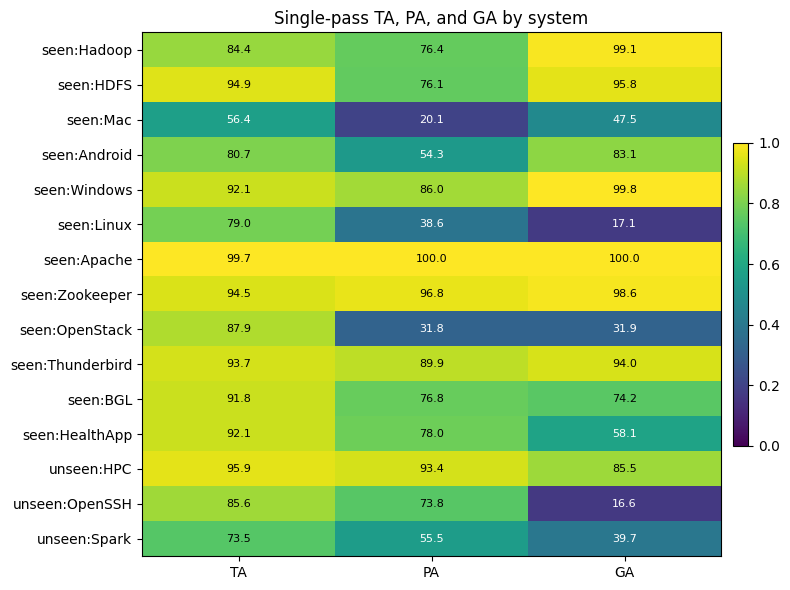

Saved heatmap: /content/outputs/figures/metric_heatmap.png


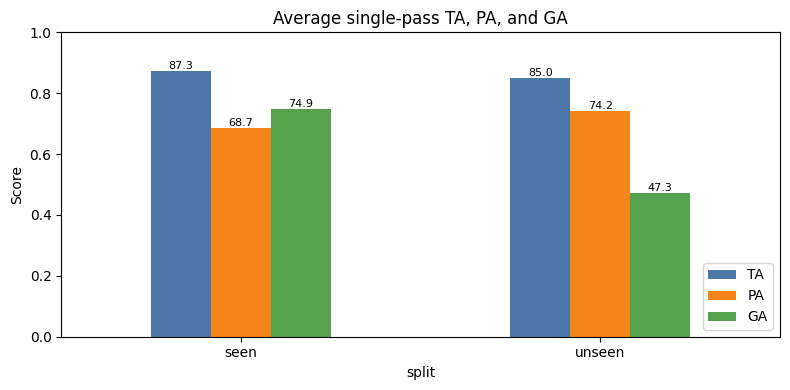

Saved bar chart: /content/outputs/figures/metric_bar_chart.png


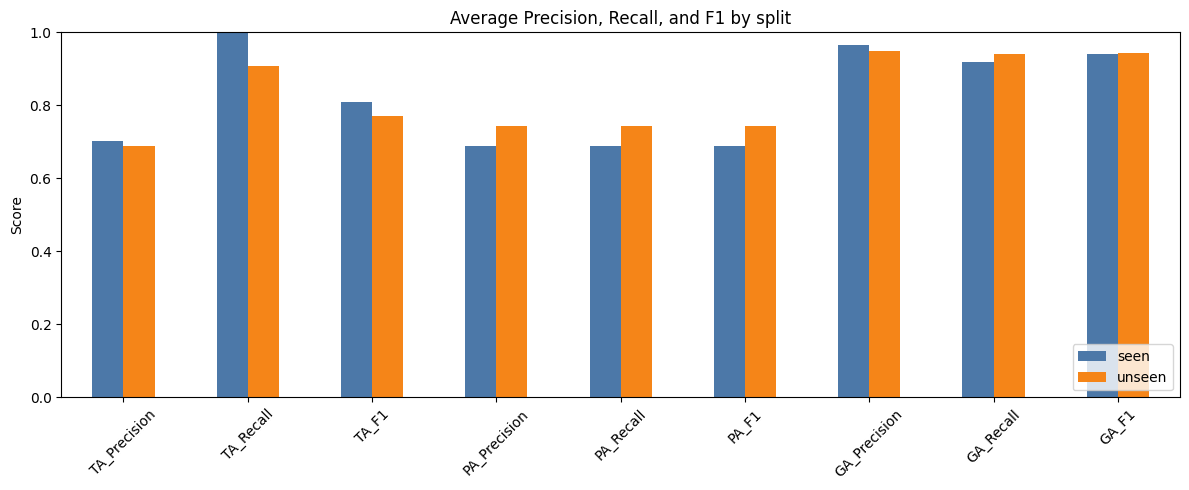

Saved precision/recall/F1 chart: /content/outputs/figures/precision_recall_f1.png


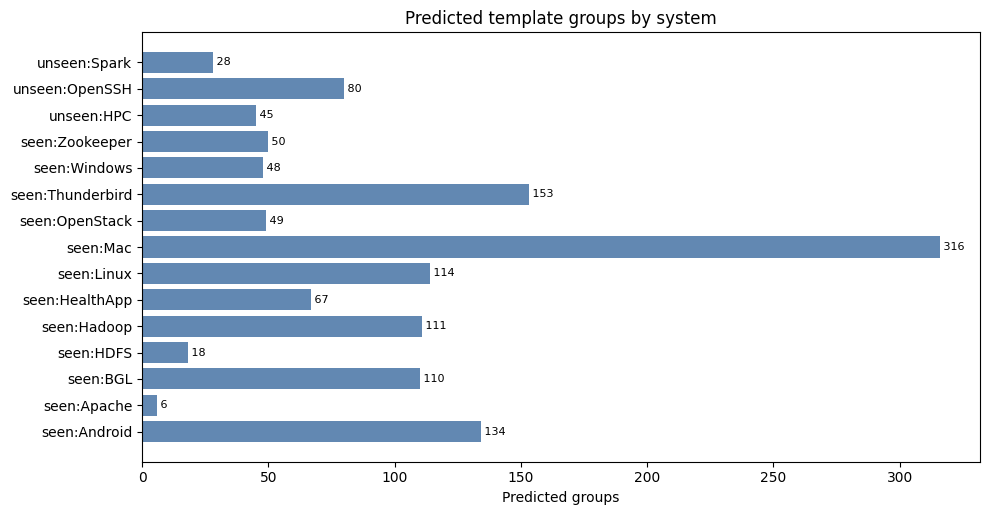

Saved grouping chart: /content/outputs/figures/grouping_behavior.png


In [18]:
# Main Result Visualizations
import matplotlib.pyplot as plt


def plot_metric_heatmap(summary_df, path=None):
    path = path or FIGURE_DIR / "metric_heatmap.png"
    metrics = ["TA", "PA", "GA"]
    df = summary_df.copy()
    df["label"] = df["split"] + ":" + df["system"]
    data = df[metrics].astype(float).to_numpy()

    fig_h = max(6, 0.35 * len(df))
    fig, ax = plt.subplots(figsize=(8, fig_h))
    im = ax.imshow(data, aspect="auto", vmin=0, vmax=1, cmap="viridis")
    ax.set_xticks(range(len(metrics)), metrics)
    ax.set_yticks(range(len(df)), df["label"])
    ax.set_title("Single-pass TA, PA, and GA by system")
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            value = data[i, j]
            label = "N/A" if np.isnan(value) else f"{value * 100:.1f}"
            ax.text(j, i, label, ha="center", va="center", color="white" if value < 0.72 else "black", fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    fig.tight_layout()
    fig.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Saved heatmap: {path}")


def plot_seen_unseen_bars(summary_df, path=None):
    path = path or FIGURE_DIR / "metric_bar_chart.png"
    metrics = ["TA", "PA", "GA"]
    grouped = summary_df.groupby("split")[metrics].mean(numeric_only=True).reindex(["seen", "unseen"])
    ax = grouped.plot(kind="bar", figsize=(8, 4), ylim=(0, 1), rot=0, color=["#4C78A8", "#F58518", "#54A24B"])
    ax.set_title("Average single-pass TA, PA, and GA")
    ax.set_ylabel("Score")
    ax.legend(loc="lower right")
    for container in ax.containers:
        ax.bar_label(container, labels=[f"{v.get_height() * 100:.1f}" for v in container], fontsize=8)
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Saved bar chart: {path}")


def plot_precision_recall_f1(summary_df, path=None):
    path = path or FIGURE_DIR / "precision_recall_f1.png"
    metric_cols = [
        "TA_Precision", "TA_Recall", "TA_F1",
        "PA_Precision", "PA_Recall", "PA_F1",
        "GA_Precision", "GA_Recall", "GA_F1",
    ]
    available = [c for c in metric_cols if c in summary_df.columns]
    if not available:
        return
    grouped = summary_df.groupby("split")[available].mean(numeric_only=True).reindex(["seen", "unseen"])
    ax = grouped.T.plot(kind="bar", figsize=(12, 5), ylim=(0, 1), rot=45, color=["#4C78A8", "#F58518"])
    ax.set_title("Average Precision, Recall, and F1 by split")
    ax.set_ylabel("Score")
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Saved precision/recall/F1 chart: {path}")


def plot_grouping_behavior(groups_df, path=None):
    path = path or FIGURE_DIR / "grouping_behavior.png"
    if groups_df.empty:
        return
    plot_df = groups_df.groupby(["split", "system"]).agg(
        groups=("pred_group_id", "nunique"),
    ).reset_index()
    plot_df["label"] = plot_df["split"] + ":" + plot_df["system"]

    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(plot_df))))
    ax.barh(plot_df["label"], plot_df["groups"], color="#4C78A8", alpha=0.88)
    ax.set_xlabel("Predicted groups")
    ax.set_ylabel("")
    ax.set_title("Predicted template groups by system")
    for idx, value in enumerate(plot_df["groups"]):
        ax.text(value, idx, f" {int(value)}", va="center", fontsize=8)
    fig.tight_layout()
    fig.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Saved grouping chart: {path}")


plot_metric_heatmap(evaluation_tables["summary"])
plot_seen_unseen_bars(evaluation_tables["summary"])
plot_precision_recall_f1(evaluation_tables["summary"])
plot_grouping_behavior(evaluation_tables["groups"])


In [ ]:
# Experiment Configuration
from collections import Counter


TARGET_SEEN_LOO_SYSTEMS = ["Hadoop", "Zookeeper", "HealthApp"]
TARGET_UNSEEN_SYSTEMS = ["HPC", "OpenSSH", "Spark"]
TARGETED_EXPORT_PATH = TARGETED_WORKBOOK_PATH


def _available_unseen_systems(names=None):
    names = names or TARGET_UNSEEN_SYSTEMS
    return [
        name for name in names
        if name in UNSEEN_SYSTEMS and os.path.exists(UNSEEN_SYSTEMS[name]["log"])
    ]


def _validate_seen_systems(names):
    missing = [name for name in names if name not in all_systems]
    if missing:
        raise ValueError(f"Seen systems not available: {missing}")
    return list(names)


def _validate_unseen_systems(names):
    available = _available_unseen_systems(names)
    missing = [name for name in names if name not in available]
    if missing:
        print(f"Skipping unavailable unseen systems: {missing}")
    return available


def _same_epoch_experiment_cfg(overrides=None):

    cfg = {
        "meta_epochs": CONFIG["meta_epochs"],
        "tasks_per_epoch": CONFIG["tasks_per_epoch"],
        "print_every": CONFIG["print_every"],
        "pooled_epochs": CONFIG["meta_epochs"],
        "pooled_batch_size": CONFIG.get("pooled_batch_size", 128),
    }
    if overrides:
        cfg.update(overrides)
    return cfg


def _show_dataframe(df, title=None, max_rows=None):
    if title:
        print("\n" + title)
    view = df.head(max_rows) if max_rows else df
    try:
        display(view)
    except NameError:
        print(view.to_string(index=False))


def _percent_view(df, metric_cols=None):
    metric_cols = metric_cols or ["TA", "TA_Precision", "TA_Recall", "TA_F1", "PA", "PA_Precision", "PA_Recall", "PA_F1", "GA", "GA_Precision", "GA_Recall", "GA_F1"]
    shown = df.copy()
    for col in metric_cols:
        if col in shown.columns:
            shown[col] = shown[col].map(lambda v: None if pd.isna(v) else round(100 * float(v), 2))
    return shown


class MANNLayerNoMemory(nn.Module):
    """Same projection/controller shape as MANN, but no memory read/write effect."""
    def __init__(self, W_proj_tensor, create_th, cfg=CONFIG, svd_mean=None):
        super().__init__()
        D, H, NS = cfg["mem_dim"], cfg["hidden_dim"], cfg["n_slots"]
        self.D = D
        self.H = H
        self.n_slots = NS
        self.create_th = create_th
        self.register_buffer("W_proj", torch.as_tensor(W_proj_tensor, dtype=torch.float32))
        if svd_mean is None:
            svd_mean = torch.zeros(self.W_proj.shape[1], dtype=torch.float32)
        self.register_buffer("svd_mean", torch.as_tensor(svd_mean, dtype=torch.float32))
        self.register_buffer("M", torch.zeros(NS, D))
        self.register_buffer("usage", torch.zeros(NS))
        self.controller = MLP(D, H, cfg["mlp_dropout"])

    def reset_memory(self):
        self.M.zero_()
        self.usage.zero_()

    def _project(self, x):
        if x.shape[-1] == self.D:
            return nn.functional.normalize(x, dim=-1)
        return nn.functional.normalize((x - self.svd_mean.to(x.device)) @ self.W_proj.to(x.device).T, dim=-1)

    def forward(self, x, verbose=False, write=True):
        batched = x.dim() == 2
        if not batched:
            x = x.unsqueeze(0)
        z = self.controller(self._project(x))
        return z.squeeze(0) if not batched else z


class MemAIDNoMemory(MemAID):
    def __init__(self, encoder_dim, W_proj, create_th, cfg=CONFIG, svd_mean=None):
        nn.Module.__init__(self)
        self.cfg = cfg
        self.mann = MANNLayerNoMemory(W_proj, create_th, cfg, svd_mean=svd_mean)
        self.classifier = TokenClassifier(cfg["hidden_dim"])
        self.memory_enabled = False
        self.label_memory = []

    def _compute_mem_sim(self, x):
        return 0.0

    def _best_memory_slot(self, x):
        return None

    def _memory_label_scores(self, x, tokens):
        return [0.0] * len(tokens), 0.0, None

    def write_label_memory(self, x, tokens, labels, template=None, confidence=1.0):
        return


def clone_records(records, keep_gt=True):
    cloned = []
    for r in records:
        c = dict(r)
        c["tokens"] = list(r.get("tokens", []))
        c["token_labels"] = list(r.get("token_labels", [])) if r.get("token_labels") is not None else None
        c["x_np"] = np.array(r["x_np"], dtype=np.float32)
        c["x"] = r["x"].detach().clone() if isinstance(r.get("x"), torch.Tensor) else None
        if r.get("gt_labels") is not None:
            c["gt_labels"] = list(r["gt_labels"])
        if not keep_gt:
            c["gt_template"] = None
            c["gt_labels"] = None
            c["gt_alignment"] = None
        cloned.append(c)
    return cloned


_EXPERIMENT_RECORD_CACHE = {}
_SEEN_RAW_RECORD_CACHE = {}


def _load_seen_raw_records_for_eval(system_name):
    """Seen-system raw records prepared with the same labeled-data boundary correction."""
    if system_name not in _SEEN_RAW_RECORD_CACHE:
        paths = SYSTEMS[system_name]
        records, _ = parse_records(paths["log"], paths.get("structured"))
        prepare_labeled_records(records, paths.get("structured"))
        encode_records(records, enc)
        for r in records:
            r["system"] = system_name
        _SEEN_RAW_RECORD_CACHE[system_name] = records
    return _SEEN_RAW_RECORD_CACHE[system_name]


def get_records_for_experiment(system_name, keep_gt=True, use_gt_corrected=True):
    if system_name in all_systems:
        base = all_systems[system_name] if use_gt_corrected else _load_seen_raw_records_for_eval(system_name)
        return clone_records(base, keep_gt=keep_gt)

    if system_name not in UNSEEN_SYSTEMS or not os.path.exists(UNSEEN_SYSTEMS[system_name]["log"]):
        raise ValueError(f"System is not available for experiments: {system_name}")

    if system_name not in _EXPERIMENT_RECORD_CACHE:
        records, _ = parse_records(UNSEEN_SYSTEMS[system_name]["log"], UNSEEN_SYSTEMS[system_name].get("structured"))
        prepare_labeled_records(records, UNSEEN_SYSTEMS[system_name].get("structured"))
        encode_records(records, enc)
        for r in records:
            r["system"] = system_name
        _EXPERIMENT_RECORD_CACHE[system_name] = records

    return clone_records(_EXPERIMENT_RECORD_CACHE[system_name], keep_gt=keep_gt)


def fit_svd_from_embeddings(embeddings, target_dim=CONFIG["mem_dim"]):
    X = np.stack(embeddings).astype(np.float64)
    mean = X.mean(axis=0, keepdims=True)
    Xc = X - mean
    _, _, Vt = np.linalg.svd(Xc, full_matrices=False)
    n = min(len(embeddings), target_dim)

    if n >= target_dim:
        W = Vt[:target_dim].astype(np.float32)
    else:
        rng = np.random.default_rng(CONFIG["seed"])
        pad = rng.normal(0, 1, (target_dim - n, X.shape[1])).astype(np.float32)
        pad /= np.linalg.norm(pad, axis=1, keepdims=True)
        W = np.vstack([Vt[:n].astype(np.float32), pad])

    return torch.tensor(W, dtype=torch.float32), mean.squeeze(0).astype(np.float32)


def project_system_map(system_map, W_proj_local, svd_mean_local):
    for records in system_map.values():
        project_records(records, [r["x_np"] for r in records], W_proj_local, svd_mean_local)


def experiment_pos_weight(system_map, floor=CONFIG["pos_weight_floor"], cap=CONFIG["pos_weight_cap"]):
    return max(compute_pos_weight(system_map, cap=cap), floor)


def build_model_variant(variant, W_proj_local, svd_mean_local, create_th_local, cfg):
    if variant == "no_memory":
        return MemAIDNoMemory(enc.dim, W_proj_local, create_th_local, cfg=cfg, svd_mean=svd_mean_local).to(DEVICE)
    if variant == "full":
        return MemAID(enc.dim, W_proj_local, create_th_local, cfg=cfg, svd_mean=svd_mean_local).to(DEVICE)
    raise ValueError(f"Unsupported targeted variant: {variant}")


def pooled_train(model, train_systems, pos_weight, cfg, device=DEVICE, quiet=True):
    records = [r for recs in train_systems.values() for r in recs if record_has_trainable_labels(r)]
    if not records:
        return []

    opt = optim.Adam([p for p in model.parameters() if p.requires_grad], lr=cfg["meta_lr"])
    rng = np.random.default_rng(cfg["seed"])
    losses = []
    batch_size = min(cfg.get("pooled_batch_size", 128), len(records))

    for epoch in range(cfg.get("pooled_epochs", CONFIG["meta_epochs"])):
        idx = rng.choice(len(records), size=batch_size, replace=len(records) < batch_size)
        batch = [records[int(i)] for i in idx]
        loss = compute_loss(model, batch, pos_weight, device)
        if loss is None:
            continue
        opt.zero_grad()
        loss.backward()
        opt.step()
        losses.append(float(loss.item()))

        should_print = epoch == 0 or (epoch + 1) % cfg["print_every"] == 0 or epoch + 1 == cfg.get("pooled_epochs", CONFIG["meta_epochs"])
        if not quiet and should_print:
            print(f"pooled epoch {epoch + 1:>3}/{cfg.get('pooled_epochs', CONFIG['meta_epochs'])} loss={losses[-1]:.4f}")

    return losses


def train_targeted_experiment_model(
    train_system_names,
    variant="full",
    use_meta=True,
    report_variant=None,
    cfg_overrides=None,
    quiet=True,
    keep_gt_for_training=True,
):
    cfg = dict(CONFIG)
    cfg.update(_same_epoch_experiment_cfg(cfg_overrides))

    train_system_names = list(train_system_names)
    train_map = {
        name: get_records_for_experiment(name, keep_gt=keep_gt_for_training)
        for name in train_system_names
    }
    train_flat = [r for recs in train_map.values() for r in recs]

    W_local, mean_local = fit_svd_from_embeddings([r["x_np"] for r in train_flat], cfg["mem_dim"])
    project_system_map(train_map, W_local, mean_local)

    create_th_local = calibrate_create_th(train_flat, W_local, mean_local, cfg)
    pos_weight_local = experiment_pos_weight(train_map)
    exp_model = build_model_variant(variant, W_local, mean_local, create_th_local, cfg)

    if use_meta:
        losses_local = maml_train(exp_model, train_map, pos_weight_local, cfg, DEVICE, quiet=quiet)
    else:
        losses_local = pooled_train(exp_model, train_map, pos_weight_local, cfg, DEVICE, quiet=quiet)

    return {
        "model": exp_model,
        "variant": variant,
        "report_variant": report_variant or ("full" if variant == "full" and use_meta else variant),
        "use_meta": use_meta,
        "train_systems": train_system_names,
        "W_proj": W_local,
        "svd_mean": mean_local,
        "create_th": create_th_local,
        "pos_weight": pos_weight_local,
        "cfg": cfg,
        "losses": losses_local,
        "keep_gt_for_training": keep_gt_for_training,
    }


def prepare_records_for_eval(system_name, exp, keep_gt=True, use_gt_corrected=True):
    records = get_records_for_experiment(system_name, keep_gt=keep_gt, use_gt_corrected=use_gt_corrected)
    project_records(records, [r["x_np"] for r in records], exp["W_proj"], exp["svd_mean"])
    return records


def adapt_model_for_records(base_model, support_records, exp):
    support = support_records[:CONFIG["unseen_adapt_lines"]]
    adapted = inner_loop(
        base_model,
        support,
        CONFIG["adapt_lr"],
        CONFIG["unseen_adapt_steps"],
        exp["pos_weight"],
        DEVICE,
    )
    adapted.mann.create_th = max(float(adapted.mann.create_th), CONFIG["unseen_create_th_floor"])
    adapted.eval()
    return adapted



def experiment_average_dataframe(df):
    metrics = [
        "TA", "TA_Precision", "TA_Recall", "TA_F1",
        "PA", "PA_Precision", "PA_Recall", "PA_F1",
        "GA", "GA_Precision", "GA_Recall", "GA_F1",
    ]
    if df is None or df.empty:
        return pd.DataFrame()
    rows = []
    group_cols = [c for c in ["experiment", "phase", "variant"] if c in df.columns]
    for keys, part in df.groupby(group_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = dict(zip(group_cols, keys))
        row["systems"] = len(part)
        for metric in metrics:
            if metric in part.columns:
                row[metric] = part[metric].mean(skipna=True)
        rows.append(row)
    return pd.DataFrame(rows)


def metric_dict_to_row(experiment, phase, system_name, variant, train_systems, metrics):
    row = {
        "experiment": experiment,
        "phase": phase,
        "system": system_name,
        "variant": variant,
        "train_systems": "+".join(train_systems) if isinstance(train_systems, (list, tuple)) else str(train_systems),
        "TA": metrics.get("ta"),
        "TA_Precision": metrics.get("ta_precision"),
        "TA_Recall": metrics.get("ta_recall"),
        "TA_F1": metrics.get("ta_f1"),
        "PA": metrics.get("pa"),
        "PA_Precision": metrics.get("pa_precision"),
        "PA_Recall": metrics.get("pa_recall"),
        "PA_F1": metrics.get("pa_f1"),
        "GA": metrics.get("ga"),
        "GA_Precision": metrics.get("ga_precision"),
        "GA_Recall": metrics.get("ga_recall"),
        "GA_F1": metrics.get("ga_f1"),
        "lines": metrics.get("n_lines"),
        "tokens": metrics.get("n_tokens"),
        "active_slots": metrics.get("active_slots"),
    }
    return row


def evaluate_targeted_experiment(exp, system_name, experiment, phase, adapt=False, quiet=True):
    use_gt_corrected = not phase.startswith("test")
    eval_records = prepare_records_for_eval(system_name, exp, keep_gt=True, use_gt_corrected=use_gt_corrected)
    eval_model = exp["model"]
    reset_memory = True

    # Only meta-trained variants get target support adaptation.
    # This is intentional: removing MAML should remove fast support-set learning.
    if adapt and exp.get("use_meta", False):
        adapt_records = prepare_records_for_eval(system_name, exp, keep_gt=False, use_gt_corrected=False)
        eval_model = adapt_model_for_records(exp["model"], adapt_records, exp)
        reset_memory = False

    score_records = eval_records[CONFIG["unseen_adapt_lines"]:] if adapt else eval_records
    metrics = evaluate(
        eval_model,
        score_records,
        f"{experiment}:{phase}:{system_name}:{exp['report_variant']}",
        quiet=quiet,
        reset_memory=reset_memory,
    )
    row = metric_dict_to_row(
        experiment=experiment,
        phase=phase,
        system_name=system_name,
        variant=exp["report_variant"],
        train_systems=exp["train_systems"],
        metrics=metrics,
    )
    return row, metrics


def print_metric_matrix(rows, title):
    df = pd.DataFrame(rows)
    if df.empty:
        print(f"\n{title}: no rows")
        return df

    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)

    show_cols = [
        "experiment", "phase", "system", "variant",
        "TA", "PA", "GA",
        "lines", "active_slots", "train_systems",
    ]
    _show_dataframe(_percent_view(df)[show_cols])
    return df



def ablation_summary_dataframe(ablation_df):
    metrics = [
        "TA", "TA_Precision", "TA_Recall", "TA_F1",
        "PA", "PA_Precision", "PA_Recall", "PA_F1",
        "GA", "GA_Precision", "GA_Recall", "GA_F1",
    ]
    rows = []
    for (phase, variant), part in ablation_df.groupby(["phase", "variant"]):
        row = {"phase": phase, "variant": variant, "systems": len(part)}
        for metric in metrics:
            if metric in part:
                row[metric] = part[metric].mean()
        rows.append(row)
    return pd.DataFrame(rows)



def template_pairs_dataframe(metrics_map, experiment_name, top_n=None):
    top_n = top_n or CONFIG["top_template_examples"]
    rows = []
    for key, metric in metrics_map.items():
        for status in ("Correct", "Incorrect"):
            for rank, ((gt, pred), freq) in enumerate(top_template_pairs(metric, status=status, top_n=top_n), 1):
                rows.append({
                    "experiment": experiment_name,
                    "case": key,
                    "status": status,
                    "rank": rank,
                    "freq": freq,
                    "gt": gt,
                    "pred": pred,
                })
    return pd.DataFrame(rows)


def export_targeted_workbook(
    path=TARGETED_EXPORT_PATH,
    loo_df=None,
    ablation_df=None,
    loo_pairs_df=None,
    ablation_pairs_df=None,
):
    with pd.ExcelWriter(path, engine="openpyxl") as writer:
        if loo_df is not None and not loo_df.empty:
            loo_df.to_excel(writer, sheet_name="leave_one_out", index=False)
            experiment_average_dataframe(loo_df).to_excel(writer, sheet_name="loo_averages", index=False)
        if loo_pairs_df is not None and not loo_pairs_df.empty:
            loo_pairs_df.to_excel(writer, sheet_name="loo_template_pairs", index=False)
        if ablation_df is not None and not ablation_df.empty:
            ablation_df.to_excel(writer, sheet_name="targeted_ablation", index=False)
            experiment_average_dataframe(ablation_df).to_excel(writer, sheet_name="ablation_averages", index=False)
            ablation_summary_dataframe(ablation_df).to_excel(writer, sheet_name="ablation_summary", index=False)
        if ablation_pairs_df is not None and not ablation_pairs_df.empty:
            ablation_pairs_df.to_excel(writer, sheet_name="ablation_template_pairs", index=False)
    print(f"Saved targeted experiment workbook: {path}")


print("Targeted experiment helpers loaded.")
print(f"Target seen LOO systems: {TARGET_SEEN_LOO_SYSTEMS}")
print(f"Target unseen systems: {_available_unseen_systems()}")
print("Ablation variants: full_existing, no_memory_maml, memory_no_maml")


In [ ]:
# Targeted Leave-One-Out Experiment
RUN_TARGETED_LEAVE_ONE_OUT = True


def run_targeted_seen_leave_one_out(
    holdout_systems=None,
    unseen_systems=None,
    include_train_seen=True,
    show_examples=True,
    cfg_overrides=None,
):
    holdout_systems = _validate_seen_systems(holdout_systems or TARGET_SEEN_LOO_SYSTEMS)
    unseen_systems = _validate_unseen_systems(unseen_systems or TARGET_UNSEEN_SYSTEMS)
    rows = []
    metrics_map = {}
    cfg_overrides = _same_epoch_experiment_cfg(cfg_overrides)

    print("\nRunning targeted seen-system leave-one-out")
    print(f"Only these held-out seen systems are tested: {holdout_systems}")
    print(f"Unseen systems tested after each LOO fit: {unseen_systems}")

    for case_idx, holdout_system in enumerate(holdout_systems, 1):
        train_names = [name for name in all_systems.keys() if name != holdout_system]
        print(f"\nTargeted Seen LOO {case_idx}/{len(holdout_systems)}: train={len(train_names)} systems, holdout={holdout_system}")

        exp = train_targeted_experiment_model(
            train_names,
            variant="full",
            use_meta=True,
            report_variant="full",
            cfg_overrides=cfg_overrides,
            quiet=True,
            keep_gt_for_training=True,
        )

        if include_train_seen:
            for system_name in train_names:
                row, _ = evaluate_targeted_experiment(
                    exp,
                    system_name,
                    experiment="targeted_seen_leave_one_out",
                    phase="train_seen",
                    adapt=False,
                    quiet=True,
                )
                rows.append(row)

        row, metric = evaluate_targeted_experiment(
            exp,
            holdout_system,
            experiment="targeted_seen_leave_one_out",
            phase="test_seen_holdout",
            adapt=True,
            quiet=True,
        )
        rows.append(row)
        metrics_map[f"seen_holdout:{holdout_system}"] = metric

        for unseen_name in unseen_systems:
            row, metric = evaluate_targeted_experiment(
                exp,
                unseen_name,
                experiment="targeted_seen_leave_one_out",
                phase="test_unseen",
                adapt=True,
                quiet=True,
            )
            rows.append(row)
            metrics_map[f"seen_loo_unseen:{holdout_system}->{unseen_name}"] = metric

    loo_df = print_metric_matrix(rows, "Targeted seen leave-one-out matrix")
    loo_average_df = experiment_average_dataframe(loo_df)
    print("\nLeave-one-out averages")
    _show_dataframe(_percent_view(loo_average_df), max_rows=None)
    loo_pairs_df = template_pairs_dataframe(metrics_map, "targeted_seen_leave_one_out") if show_examples else pd.DataFrame()

    if show_examples:
        print_top_template_examples(metrics_map, "targeted seen leave-one-out top template pairs")

    return loo_df, loo_average_df, loo_pairs_df


if RUN_TARGETED_LEAVE_ONE_OUT:
    targeted_loo_df, targeted_loo_average_df, targeted_loo_pairs_df = run_targeted_seen_leave_one_out()
    export_targeted_workbook(
        path=TARGETED_EXPORT_PATH,
        loo_df=targeted_loo_df,
        loo_pairs_df=targeted_loo_pairs_df,
        ablation_df=globals().get("targeted_ablation_df"),
        ablation_pairs_df=globals().get("targeted_ablation_pairs_df"),
    )
else:
    print("Targeted leave-one-out is off. Set RUN_TARGETED_LEAVE_ONE_OUT = True and rerun this cell.")


In [ ]:
# Targeted Ablation Study
RUN_TARGETED_ABLATION = True


def ensure_main_full_metrics(unseen_systems=None):
    unseen_systems = _validate_unseen_systems(unseen_systems or TARGET_UNSEEN_SYSTEMS)

    if "all_metrics" not in globals():
        print("`all_metrics` not found. Evaluating the already-trained full model on seen systems.")
        globals()["all_metrics"] = {
            name: evaluate(model, recs, name, quiet=True)
            for name, recs in all_systems.items()
        }

    if "unseen_metrics" not in globals():
        print("`unseen_metrics` not found. Evaluating the already-trained full model on unseen systems.")
        globals()["unseen_metrics"] = evaluate_unseen_systems(
            {name: UNSEEN_SYSTEMS[name] for name in unseen_systems},
            adapt=True,
        )

    return globals()["all_metrics"], globals()["unseen_metrics"]


def full_existing_rows_from_main_metrics(seen_metrics, unseen_metrics, unseen_systems):
    rows = []
    seen_train_label = "+".join(all_systems.keys())

    for system_name, metric in seen_metrics.items():
        rows.append(metric_dict_to_row(
            experiment="targeted_ablation",
            phase="train_seen",
            system_name=system_name,
            variant="full_existing",
            train_systems=seen_train_label,
            metrics=metric,
        ))

    for system_name in unseen_systems:
        if system_name in unseen_metrics:
            rows.append(metric_dict_to_row(
                experiment="targeted_ablation",
                phase="test_unseen",
                system_name=system_name,
                variant="full_existing",
                train_systems=seen_train_label,
                metrics=unseen_metrics[system_name],
            ))

    return rows


def run_targeted_ablation_existing_full(
    unseen_systems=None,
    include_train_seen=True,
    show_examples=True,
    cfg_overrides=None,
):
    unseen_systems = _validate_unseen_systems(unseen_systems or TARGET_UNSEEN_SYSTEMS)
    seen_metrics, main_unseen_metrics = ensure_main_full_metrics(unseen_systems)
    cfg_overrides = _same_epoch_experiment_cfg(cfg_overrides)

    rows = full_existing_rows_from_main_metrics(seen_metrics, main_unseen_metrics, unseen_systems)
    metrics_map = {
        f"full_existing:unseen:{name}": main_unseen_metrics[name]
        for name in unseen_systems
        if name in main_unseen_metrics
    }

    variants = [
        {
            "report_variant": "no_memory_maml",
            "variant": "no_memory",
            "use_meta": True,
            "description": "MAML kept, memory removed",
        },
        {
            "report_variant": "memory_no_maml",
            "variant": "full",
            "use_meta": False,
            "cfg_overrides": {"use_token_rule_features": False},
            "description": "Memory kept, MAML and token-rule features removed",
        },
    ]

    print("\nRunning targeted ablation")
    print("Baseline is the already-trained main full model: full_existing")
    print("For memory_no_maml, MAML adaptation and token-rule features are disabled.")
    print("For no_memory_maml, GA is computed from post-hoc predicted-template groups; it is not memory-backed grouping.")
    print(f"Same training epochs as main model: meta_epochs={CONFIG['meta_epochs']}, tasks_per_epoch={CONFIG['tasks_per_epoch']}")
    print(f"Unseen systems: {unseen_systems}")

    for spec in variants:
        print(f"\nAblation variant: {spec['report_variant']} ({spec['description']})")
        exp = train_targeted_experiment_model(
            list(all_systems.keys()),
            variant=spec["variant"],
            use_meta=spec["use_meta"],
            report_variant=spec["report_variant"],
            cfg_overrides={**cfg_overrides, **spec.get("cfg_overrides", {})},
            quiet=True,
            keep_gt_for_training=True,
        )

        if include_train_seen:
            for system_name in all_systems.keys():
                row, metric = evaluate_targeted_experiment(
                    exp,
                    system_name,
                    experiment="targeted_ablation",
                    phase="train_seen",
                    adapt=False,
                    quiet=True,
                )
                rows.append(row)
                metrics_map[f"{spec['report_variant']}:seen:{system_name}"] = metric

        for system_name in unseen_systems:
            row, metric = evaluate_targeted_experiment(
                exp,
                system_name,
                experiment="targeted_ablation",
                phase="test_unseen",
                adapt=True,
                quiet=True,
            )
            rows.append(row)
            metrics_map[f"{spec['report_variant']}:unseen:{system_name}"] = metric

    ablation_df = print_metric_matrix(rows, "Targeted ablation: full_existing vs removed-component variants")
    average_df = experiment_average_dataframe(ablation_df)
    summary_df = ablation_summary_dataframe(ablation_df)
    pairs_df = template_pairs_dataframe(metrics_map, "targeted_ablation") if show_examples else pd.DataFrame()

    print("\nAblation summary by phase and variant")
    _show_dataframe(_percent_view(summary_df), max_rows=None)



    if show_examples:
        unseen_metric_examples = {k: v for k, v in metrics_map.items() if ":unseen:" in k}
        print_top_template_examples(unseen_metric_examples, "targeted ablation top template pairs on unseen systems")

    return ablation_df, average_df, summary_df, pairs_df


if RUN_TARGETED_ABLATION:
    (
        targeted_ablation_df,
        targeted_ablation_average_df,
        targeted_ablation_summary_df,
        targeted_ablation_pairs_df,
    ) = run_targeted_ablation_existing_full()

    export_targeted_workbook(
        path=TARGETED_EXPORT_PATH,
        loo_df=globals().get("targeted_loo_df"),
        loo_pairs_df=globals().get("targeted_loo_pairs_df"),
        ablation_df=targeted_ablation_df,
        ablation_pairs_df=targeted_ablation_pairs_df,
    )
else:
    print("Targeted ablation is off. Set RUN_TARGETED_ABLATION = True and rerun this cell.")


In [22]:
# Save Model Artifacts
def json_safe(value):
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, (np.floating, np.integer)):
        value = value.item()
    if isinstance(value, float) and not np.isfinite(value):
        return None
    if isinstance(value, np.bool_):
        return bool(value)
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, torch.Tensor):
        return value.detach().cpu().tolist()
    if isinstance(value, dict):
        return {str(k): json_safe(v) for k, v in value.items() if k != "predictions"}
    if isinstance(value, (list, tuple, set)):
        return [json_safe(v) for v in value]
    return value


checkpoint_path = CHECKPOINT_PATH
results_path = RESULTS_JSON_PATH

torch.save({
    "model_state": model.state_dict(),
    "W_proj": W_proj,
    "svd_mean": SVD_MEAN,
    "create_th": CREATE_TH,
    "pos_weight": POS_WEIGHT,
    "config": CONFIG,
    "encoder_dim": enc.dim,
    "meta_losses": losses,
    "trained_systems": list(all_systems.keys()),
}, checkpoint_path)

results_payload = {
    "training_metrics": all_metrics,
    "unseen_metrics": unseen_metrics,
    "comparison_files": {
        "workbook": MAIN_WORKBOOK_PATH,
        "heatmap": FIGURE_DIR / "metric_heatmap.png",
        "bars": FIGURE_DIR / "metric_bar_chart.png",
        "precision_recall_f1": FIGURE_DIR / "precision_recall_f1.png",
        "grouping": FIGURE_DIR / "grouping_behavior.png",
    },
    "meta_losses": losses,
    "experiment_tables": {
        "targeted_leave_one_out": targeted_loo_df.to_dict("records") if "targeted_loo_df" in globals() else None,
        "targeted_ablation": targeted_ablation_df.to_dict("records") if "targeted_ablation_df" in globals() else None,
        "targeted_ablation_averages": targeted_ablation_average_df.to_dict("records") if "targeted_ablation_average_df" in globals() else None,
    },
    "config": CONFIG,
    "trained_systems": list(all_systems.keys()),
}

with open(results_path, "w") as f:
    json.dump(json_safe(results_payload), f, indent=2)

print(f"Saved {checkpoint_path}")
print(f"Saved {results_path}")


Saved /content/outputs/models/memaid_checkpoint.pt
Saved /content/outputs/reports/model_results.json


## Architecture Workflow

```mermaid
flowchart TD
    A["Raw log files"] --> B["UniversalLogParser.parse_batch()"]
    B --> B1["Detected metadata boundary"]
    B --> B2["Raw content tokens"]
    B2 --> C["attach_ground_truth()"]
    C --> C1["GT labels and templates"]
    C1 --> C2["structured Content teacher correction"]
    C2 --> D["Encoder.encode()"]
    D --> E["Encoder.fit_svd() + project_embeddings()"]
    E --> F["MANNLayer"]
    F --> G["TokenClassifier"]
    G --> H["model.predict_line()"]
    H --> H2["template reuse"]
    H2 --> I["Predicted template"]
    I --> J["evaluate()"]
    C1 --> J
    J --> K["TA, PA, GA + precision, recall, F1"]
    J --> L["Excel, JSON, PNG outputs"]
```

### Runtime Dimension Flow

The `Component Dimension Inspection` cell derives every dimension from live function calls and object shapes.

| Component | Runtime expression | Output |
|---|---|---|
| Sentence embedding | `enc.encode(sample_contents).shape` | Dense vector per sampled log line |
| SVD projection matrix | `W_proj.shape` after `enc.fit_svd(all_embeddings)` | Projection from encoder space into memory space |
| SVD-projected vector | `project_embeddings(raw_embeddings, W_proj, SVD_MEAN).shape` | Memory-space vector per sampled log line |
| MANN memory matrix | `model.mann.M.shape` | Memory slots by memory dimension |
| Controller output | `model.mann.controller(model.mann._project(sample_x.unsqueeze(0))).shape` | MLP hidden representation |
| Read query | `model.mann.W_q(controller_output).shape` | Query vector for memory lookup |
| Read scores | `read_query @ normalize(model.mann.M).T` | Similarity score per memory slot |
| Write gate | `model.mann.W_gate(concat(controller_output, read_vector)).shape` | Memory contribution gate |
| MANN output | `model.mann.W_o(concat(controller_output, gated_read)).shape` | Representation passed to token classifier |
| Token features | `model.classifier.build_feat_matrix(sample_tokens, ...).shape` | Feature matrix with one row per token |
| Token logits | `model.classifier(mann_forward_output, token_features).shape` | One static/variable score per token |

### MANN Layer Components

| Component | Implementation | Purpose |
|---|---|---|
| Projection path | `MANNLayer._project()` | Accepts raw encoder vectors or projected vectors and maps them into memory space |
| Controller MLP | `self.controller = MLP(D, H, ...)` | Produces hidden state `h` |
| Read query | `self.W_q(h)` | Builds query for memory-slot comparison |
| Memory matrix | `self.M` | Stores event prototypes in external memory slots |
| Read head | similarity scores + softmax attention | Produces memory read vector `r` |
| Write head | nearest-slot update or free-slot allocation | Updates memory over time |
| EMA update | `_adaptive_alpha()` | Stabilizes memory slot writes |
| Gate | `self.W_gate(concat(h, r))` | Controls memory contribution |
| Output projection | `self.W_o(concat(h, gated_r))` | Produces final MANN output `z` |
| Template reuse | `MemAID._stabilize_template()` | Reuses stable representatives to reduce GA group splitting |

### Ablation Variants

| Variant | Meta-learning | Memory | Token-rule features | GA |
|---|---:|---:|---:|---|
| `full_existing` | Yes | Yes | Yes | Reported |
| `no_memory_maml` | Yes | No | Yes | Post-hoc predicted-template grouping |
| `memory_no_maml` | No | Yes | No | Reported |
